In [1]:
AVAILABLE_SEASSONS = [
    '2021', '2022', '2023',
    '2024', '2025', '2026'
]

TAG_TEAM = 42
TAG_TEAM_NAME = "ARSENAL"

In [2]:

# Selecciones nacionales
TAG_LEAGUES = [1, 4, 5, 9, 10, 21, 22, 31, 32, 37, 536, 960]

# Premier league (Inglaterra)
TAG_LEAGUES = [39]

### Librerias

In [3]:
from google.colab import userdata

import pandas as pd
import json

# Numeric
import numpy as np
import math

# API
import time
from tqdm.notebook import tqdm
import requests
import http.client

# Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

# ML
from scipy.stats import poisson
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings

#Alternative models
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import f1_score

#Modelo final
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import precision_score, precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import label_binarize

## **Pasos iniciales**

* Funciones para hacer llamadas a la API de datos (API-FOOTBALL)

### Función para hacer llamadas a la API

In [4]:
def get_dataframe_api(endpoint:str):

  url = f"https://v3.football.api-sports.io/{endpoint}"
  headers = {
    "x-apisports-key": userdata.get("api-football-key")
  }

  r = requests.get(url=url,
                   headers=headers)

  print(f"No. errors: ", len(r.json()['errors']))
  print(f"No. results: ", r.json()['results'])
  print(f"----\n\n\n")

  return r.json()['response'], r.json()['results']

### Función para obtener el ID de los torenos del equipo seleccionado

In [5]:
def get_tag_leagues_from_especify_team():
  leagues = set()

  for sesson in AVAILABLE_SEASSONS:

    endpoint_fixtures = f"fixtures?team={TAG_TEAM}&season={sesson}"

    data_fixtures, num_api_results = get_dataframe_api(endpoint_fixtures)

    data_fixtures

    for match in data_fixtures:
        leagues.add(match["league"]["id"])

    print(f"--> Sesson: {sesson} - {leagues} <--\n\n")

  tag_leagues = np.array(sorted(leagues))

  return tag_leagues

In [6]:
TAG_LEAGUES = get_tag_leagues_from_especify_team()

No. errors:  0
No. results:  52
----



--> Sesson: 2021 - {48, 667, 45, 39} <--


No. errors:  0
No. results:  57
----



--> Sesson: 2022 - {3, 39, 937, 45, 48, 667} <--


No. errors:  0
No. results:  57
----



--> Sesson: 2023 - {866, 3, 2, 39, 937, 45, 48, 528, 667} <--


No. errors:  0
No. results:  63
----



--> Sesson: 2024 - {866, 3, 2, 39, 937, 45, 48, 528, 667} <--


No. errors:  0
No. results:  69
----



--> Sesson: 2025 - {866, 3, 2, 39, 937, 45, 48, 528, 667} <--


No. errors:  0
No. results:  1
----



--> Sesson: 2026 - {866, 3, 2, 39, 937, 45, 48, 528, 667} <--




### <font color=purple>Obtener un dataframe de un equipo específcio</font>
 * Obtiene todos los partidos de todas las ligas en las que juega el equipo

In [7]:
def get_clean_fixtures(data, target_id=42):
  processed_matches = []

  for m in data:
    is_home = m['teams']['home']['id'] == target_id

    status_match = m['fixture']['status']['short']


    if status_match != 'FT':
      continue

    team_side = 'home' if is_home else 'away'
    rival_side = 'away' if is_home else 'home'

    match_info = {
            'fixture_id': m['fixture']['id'],
            'season': m['league']['season'],
            'date': m['fixture']['date'],
            'team_name': m['teams'][team_side]['name'],
            'opponent_name': m['teams'][rival_side]['name'],
            'match_result': m['teams'][team_side]['winner'],
            'goals_for': m['goals'][team_side],
            'goals_against': m['goals'][rival_side],
            'is_home': is_home
    }

    processed_matches.append(match_info)

  return pd.DataFrame(processed_matches)

In [8]:
def get_general_results_matches():

  df_fixtures_all_sessons = []

  for sesson in AVAILABLE_SEASSONS:
    print(f"SEASON: {sesson}")

    for id_league in TAG_LEAGUES:
      print(f"ID LEAGUE: {id_league}")

      endpoint_fixtures = f"fixtures?league={id_league}&season={sesson}&team={TAG_TEAM}"

      data_fixtures, num_api_results = get_dataframe_api(endpoint_fixtures)

      if num_api_results < 1:
        continue

      df_fixtures_per_sesson = get_clean_fixtures(data_fixtures,
                                                  target_id=TAG_TEAM)

      df_fixtures_all_sessons.append(df_fixtures_per_sesson)

  df_fixtures_all_sessons = pd.concat(df_fixtures_all_sessons,
                                      ignore_index=True)

  return df_fixtures_all_sessons

### <font color="green">Obtener un dataframe de un todos los equipos</font>
 * Obtiene todos los partidos de todas las ligas especificadas en TAG_LEAGUES

In [9]:
def get_clean_fixtures_all_teams(data):
  processed_matches = []

  for m in data:
    status_match = m['fixture']['status']['short']


    if status_match != 'FT':
      continue


    match_info = {
            'fixture_id': m['fixture']['id'],
            'season': m['league']['season'],
            'date': m['fixture']['date'],
            'home_team': m['teams']['home']['name'],
            'away_team': m['teams']['away']['name'],
            'home_goals': m['goals']['home'],
            'away_goals': m['goals']['away']
    }

    processed_matches.append(match_info)

  return pd.DataFrame(processed_matches)

In [10]:
def get_general_results_matches_all_teams():

  df_fixtures_all_sessons = []

  for sesson in AVAILABLE_SEASSONS:
    print(f"SEASON: {sesson}")

    for id_league in TAG_LEAGUES:
      print(f"ID LEAGUE: {id_league}")

      endpoint_fixtures = f"fixtures?league={id_league}&season={sesson}"

      data_fixtures, num_api_results = get_dataframe_api(endpoint_fixtures)

      if num_api_results < 1:
        continue

      df_fixtures_per_sesson = get_clean_fixtures_all_teams(data_fixtures)

      df_fixtures_all_sessons.append(df_fixtures_per_sesson)

  df_fixtures_all_sessons = pd.concat(df_fixtures_all_sessons,
                                      ignore_index=True)

  return df_fixtures_all_sessons

## 📊 <font color=#258FE8>**EDA**</font> (Avance 1)

### Mostrar el data DF con estadísticas generales de los partidos

* Oponente
* Resultado
* Goles a favor
* Goles encontra
* ¿Es visitante?

In [11]:
df_fixtures_all_sessons = get_general_results_matches()

SEASON: 2021
ID LEAGUE: 2
No. errors:  0
No. results:  0
----



ID LEAGUE: 3
No. errors:  0
No. results:  0
----



ID LEAGUE: 39
No. errors:  0
No. results:  38
----



ID LEAGUE: 45
No. errors:  0
No. results:  1
----



ID LEAGUE: 48
No. errors:  0
No. results:  6
----



ID LEAGUE: 528
No. errors:  0
No. results:  0
----



ID LEAGUE: 667
No. errors:  0
No. results:  7
----



ID LEAGUE: 866
No. errors:  0
No. results:  0
----



ID LEAGUE: 937
No. errors:  0
No. results:  0
----



SEASON: 2022
ID LEAGUE: 2
No. errors:  0
No. results:  0
----



ID LEAGUE: 3
No. errors:  0
No. results:  8
----



ID LEAGUE: 39
No. errors:  0
No. results:  38
----



ID LEAGUE: 45
No. errors:  0
No. results:  2
----



ID LEAGUE: 48
No. errors:  0
No. results:  1
----



ID LEAGUE: 528
No. errors:  0
No. results:  0
----



ID LEAGUE: 667
No. errors:  0
No. results:  7
----



ID LEAGUE: 866
No. errors:  0
No. results:  0
----



ID LEAGUE: 937
No. errors:  0
No. results:  1
----



SEASON: 2023
I

In [12]:
df_fixtures_all_sessons.shape

(284, 9)

In [13]:
df_fixtures_all_sessons.head()

,fixture_id,season,date,team_name,opponent_name,match_result,goals_for,goals_against,is_home
0,710556,2021,2021-08-13T19:00:00+00:00,Arsenal,Brentford,False,0,2,False
1,710566,2021,2021-08-22T15:30:00+00:00,Arsenal,Chelsea,False,0,2,True
2,710580,2021,2021-08-28T11:30:00+00:00,Arsenal,Manchester City,False,0,5,False
3,710586,2021,2021-09-11T14:00:00+00:00,Arsenal,Norwich,True,1,0,True
4,710598,2021,2021-09-18T14:00:00+00:00,Arsenal,Burnley,True,1,0,False


Nota: Convertimos la columna 'date' a tipo de dato de fecha

In [14]:
df_fixtures_all_sessons['date'] = pd.to_datetime(df_fixtures_all_sessons['date'])
df_fixtures_all_sessons = df_fixtures_all_sessons.sort_values(by='date')
df_fixtures_all_sessons.head(2)

,fixture_id,season,date,team_name,opponent_name,match_result,goals_for,goals_against,is_home
46,736003,2021,2021-07-13 17:00:00+00:00,Arsenal,Hibernian,False,1,2,False
45,735990,2021,2021-07-17 13:00:00+00:00,Arsenal,Rangers,None,2,2,False


### Obtener estadísticas profundas de los partidos

In [15]:
df_fixtures_all_sessons_stats = []
df_no_match_information = []

for index, fixture in df_fixtures_all_sessons.iterrows():

  # Plan Pro: 300 requests per minute
  if index > 0 and (index % 300 == 0):
    for i in tqdm(range(65)):
      time.sleep(1)


  endpoint_fixtures_stats = f"fixtures/statistics?fixture={fixture['fixture_id']}&half=false"

  print(f"Index No: {index}")
  print(f"ID partido: {fixture['fixture_id']}")
  print(f"Enpoint: {endpoint_fixtures_stats}")

  data, _ = get_dataframe_api(endpoint_fixtures_stats)

  print(data)

  if not data:
    print("No match information")
    df_no_match_information.append(fixture['fixture_id'])
    continue

  team_target = next(item for item in data if item["team"]["id"] == TAG_TEAM)
  team_rival = next(item for item in data if item["team"]["id"] != TAG_TEAM)

  stats_target = {item['type']: item['value'] for item in team_target['statistics']}
  stats_rival = {item['type']: item['value'] for item in team_rival['statistics']}

  df = pd.DataFrame([{
    'team_id': team_target['team']['id'],
    'team_name': team_target['team']['name'],
    'total_shots': stats_target.get("Total Shots"),
    'shots_on_goal': stats_target.get("Shots on Goal"),
    'fouls': stats_target.get("Fouls"),
    'corner_kicks': stats_target.get("Corner Kicks"),
    'offsides': stats_target.get("Offsides"),
    'ball_possession': stats_target.get("Ball Possession"),
    'yellow_cards': stats_target.get("Yellow Cards"),
    'goalkeeper_saves': stats_target.get("Goalkeeper Saves"),
    'passes_percentage': stats_target.get("Passes %"),
    'total_passes': stats_target.get("Total passes"),
    'passes_accurate': stats_target.get("Passes accurate"),
    'shots_received': stats_rival.get("Total Shots"),
    'shots_on_goal_received': stats_rival.get("Shots on Goal"),
    'fixture_id': fixture['fixture_id'],
    'match_result': fixture['match_result'],
    'goals_for': fixture['goals_for'],
    'goals_against': fixture['goals_against'],
    'is_home': fixture['is_home'],
    'season': fixture['season']
  }])

  df_fixtures_all_sessons_stats.append(df)

print(f"{len(df_fixtures_all_sessons)}/{len(df_no_match_information)}")

df_fixtures_all_sessons_stats = pd.concat(df_fixtures_all_sessons_stats,
                                          ignore_index=True)

Index No: 46
ID partido: 736003
Enpoint: fixtures/statistics?fixture=736003&half=false
No. errors:  0
No. results:  0
----



[]
No match information
Index No: 45
ID partido: 735990
Enpoint: fixtures/statistics?fixture=735990&half=false
No. errors:  0
No. results:  0
----



[]
No match information
Index No: 49
ID partido: 745381
Enpoint: fixtures/statistics?fixture=745381&half=false
No. errors:  0
No. results:  0
----



[]
No match information
Index No: 50
ID partido: 748877
Enpoint: fixtures/statistics?fixture=748877&half=false
No. errors:  0
No. results:  0
----



[]
No match information
Index No: 47
ID partido: 736041
Enpoint: fixtures/statistics?fixture=736041&half=false
No. errors:  0
No. results:  0
----



[]
No match information
Index No: 48
ID partido: 736045
Enpoint: fixtures/statistics?fixture=736045&half=false
No. errors:  0
No. results:  0
----



[]
No match information
Index No: 0
ID partido: 710556
Enpoint: fixtures/statistics?fixture=710556&half=false
No. errors:  0

Nota: Convertirmos la columna 'ball_possession' y 'passes_percentage' a un valor floante/numérico (quitando el símbolo de porcentaje)

In [16]:
df_fixtures_all_sessons_stats['ball_possession'] = df_fixtures_all_sessons_stats['ball_possession'].str.replace('%', '').astype(float) / 100

df_fixtures_all_sessons_stats['passes_percentage'] = df_fixtures_all_sessons_stats['passes_percentage'].str.replace('%', '').astype(float) / 100

df_fixtures_all_sessons_stats[['passes_percentage', 'ball_possession']].head(2)

,passes_percentage,ball_possession
0,0.86,0.65
1,0.79,0.35


In [17]:
df_fixtures_all_sessons_stats['corner_kicks'] = pd.to_numeric(df_fixtures_all_sessons_stats['corner_kicks'], errors='coerce')
df_fixtures_all_sessons_stats['offsides'] = pd.to_numeric(df_fixtures_all_sessons_stats['offsides'], errors='coerce')
df_fixtures_all_sessons_stats['yellow_cards'] = pd.to_numeric(df_fixtures_all_sessons_stats['yellow_cards'], errors='coerce')


df_fixtures_all_sessons_stats[['corner_kicks', 'offsides', 'yellow_cards']].head(2)

,corner_kicks,offsides,yellow_cards
0,5.0,1.0,NaN
1,9.0,5.0,3.0


In [18]:
df = df_fixtures_all_sessons_stats.copy()

### **<font color='orange'>Primer vistazo</font>**

In [19]:
print(f"{len(df_no_match_information)} matches have not information about it")

print(f"\n\n{df.shape}\n\n")

df.head()

19 matches have not information about it


(265, 21)




,team_id,team_name,total_shots,shots_on_goal,fouls,corner_kicks,offsides,ball_possession,yellow_cards,goalkeeper_saves,...,total_passes,passes_accurate,shots_received,shots_on_goal_received,fixture_id,match_result,goals_for,goals_against,is_home,season
0,42,Arsenal,22,4,8,5.0,1.0,0.65,NaN,1,...,568,488,8,3,710556,False,0,2,False,2021
1,42,Arsenal,6,3,10,9.0,5.0,0.35,3.0,3,...,335,266,22,5,710566,False,0,2,True,2021
2,42,Arsenal,14,9,5,3.0,2.0,0.74,2.0,4,...,640,566,11,4,766563,True,6,0,False,2021
3,42,Arsenal,1,0,7,0.0,3.0,0.20,2.0,5,...,185,125,25,10,710580,False,0,5,False,2021
4,42,Arsenal,30,7,9,8.0,2.0,0.52,1.0,1,...,437,365,10,1,710586,True,1,0,True,2021


### **<font color='orange'>Descripción general de la forma y los tipos de datos</font>**

In [20]:
print("Dimensiones del dataset de partidos:", df.shape)
print("\nColumnas disponibles:")
display(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

display(df.head())


Dimensiones del dataset de partidos: (265, 21)

Columnas disponibles:


['team_id',
 'team_name',
 'total_shots',
 'shots_on_goal',
 'fouls',
 'corner_kicks',
 'offsides',
 'ball_possession',
 'yellow_cards',
 'goalkeeper_saves',
 'passes_percentage',
 'total_passes',
 'passes_accurate',
 'shots_received',
 'shots_on_goal_received',
 'fixture_id',
 'match_result',
 'goals_for',
 'goals_against',
 'is_home',
 'season']


Tipos de datos:
team_id                     int64
team_name                  object
total_shots                 int64
shots_on_goal               int64
fouls                       int64
corner_kicks              float64
offsides                  float64
ball_possession           float64
yellow_cards              float64
goalkeeper_saves           object
passes_percentage         float64
total_passes                int64
passes_accurate             int64
shots_received              int64
shots_on_goal_received      int64
fixture_id                  int64
match_result               object
goals_for                   int64
goals_against               int64
is_home                      bool
season                      int64
dtype: object


,team_id,team_name,total_shots,shots_on_goal,fouls,corner_kicks,offsides,ball_possession,yellow_cards,goalkeeper_saves,...,total_passes,passes_accurate,shots_received,shots_on_goal_received,fixture_id,match_result,goals_for,goals_against,is_home,season
0,42,Arsenal,22,4,8,5.0,1.0,0.65,NaN,1,...,568,488,8,3,710556,False,0,2,False,2021
1,42,Arsenal,6,3,10,9.0,5.0,0.35,3.0,3,...,335,266,22,5,710566,False,0,2,True,2021
2,42,Arsenal,14,9,5,3.0,2.0,0.74,2.0,4,...,640,566,11,4,766563,True,6,0,False,2021
3,42,Arsenal,1,0,7,0.0,3.0,0.20,2.0,5,...,185,125,25,10,710580,False,0,5,False,2021
4,42,Arsenal,30,7,9,8.0,2.0,0.52,1.0,1,...,437,365,10,1,710586,True,1,0,True,2021


### **<font color='orange'>Valores faltantes en el conjunto de datos</font>**

,missing_count,missing_percent
team_id,0,0.00
team_name,0,0.00
total_shots,0,0.00
shots_on_goal,0,0.00
fouls,0,0.00
corner_kicks,1,0.38
offsides,12,4.53
ball_possession,0,0.00
yellow_cards,12,4.53
goalkeeper_saves,1,0.38


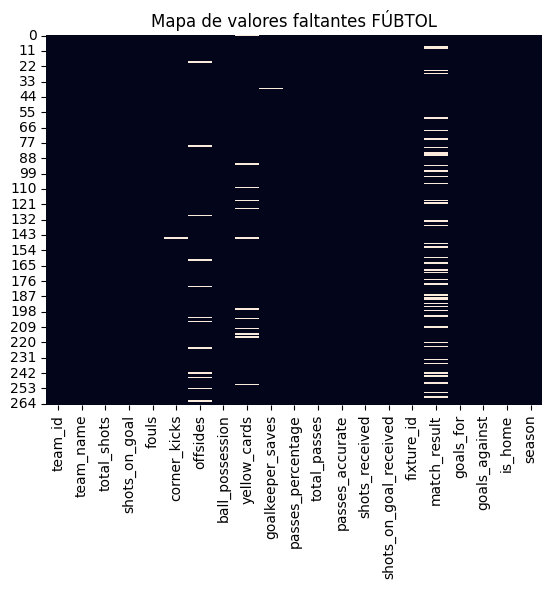

In [21]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

display(missing_summary)

sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de valores faltantes FÚBTOL")
plt.show()


### **<font color='orange'>Estadísticas descriptivas y de frecuencia</font>**

In [22]:
df.drop(columns=['team_id', 'fixture_id', 'season']).describe().T

,count,mean,std,min,25%,50%,75%,max
total_shots,265.0,15.022642,5.605011,1.00,11.00,14.00,18.00,36.00
shots_on_goal,265.0,5.275472,2.630597,0.00,3.00,5.00,7.00,16.00
fouls,265.0,10.139623,3.478197,0.00,8.00,10.00,12.00,22.00
corner_kicks,264.0,6.015152,3.214712,0.00,4.00,5.00,8.00,17.00
offsides,253.0,1.849802,1.469657,0.00,1.00,2.00,3.00,8.00
ball_possession,265.0,0.566566,0.114841,0.20,0.49,0.57,0.65,0.82
yellow_cards,253.0,1.648221,1.246729,0.00,1.00,1.00,2.00,6.00
passes_percentage,265.0,0.847774,0.049810,0.49,0.83,0.86,0.88,0.93
total_passes,265.0,501.626415,117.682933,88.00,433.00,500.00,581.00,895.00
passes_accurate,265.0,429.667925,117.158866,69.00,360.00,424.00,503.00,827.00


Nota: Match result se divide en

1.   True: Partido ganado
2.   False: Partido perdido
3.   None: Partido empatado



In [23]:
df.drop(columns=['team_id', 'fixture_id']).describe(include=['object', 'bool']).T

,count,unique,top,freq
team_name,265,1,Arsenal,265
goalkeeper_saves,264,10,1,78
match_result,220,2,True,169
is_home,265,2,False,134


In [24]:
display(df['match_result'].value_counts(dropna=False))

,count
match_result,
True,169
False,51
None,45


### Hacer el resultado del partido en categorías tipo 'one-hot-encoding'

* Victoria = 2
* Empate = 1
* Derrota = 0

In [25]:
df['is_home'] = pd.Categorical(df['is_home'],
                                    categories=[True, False])

df['match_result'] = pd.Categorical(df['match_result'],
                                    categories=[True, False])

df_dummies = pd.get_dummies(df['match_result'],
                            prefix='res',
                            dummy_na=True)

df_dummies = df_dummies.rename(columns={
    'res_True': 'victoria',
    'res_False': 'derrota',
    'res_nan': 'empate'
})

df = pd.concat([df,
                df_dummies], axis=1)

mapping = {
    'victoria': 2, # Changed from 3 to 2
    'empate': 1,
    'derrota': 0
}

df['result_num'] = df[['victoria', 'empate', 'derrota']].idxmax(axis=1).map(mapping)

df.head(25)

,team_id,team_name,total_shots,shots_on_goal,fouls,corner_kicks,offsides,ball_possession,yellow_cards,goalkeeper_saves,...,fixture_id,match_result,goals_for,goals_against,is_home,season,victoria,derrota,empate,result_num
0,42,Arsenal,22,4,8,5.0,1.0,0.65,NaN,1,...,710556,False,0,2,False,2021,False,True,False,0
1,42,Arsenal,6,3,10,9.0,5.0,0.35,3.0,3,...,710566,False,0,2,True,2021,False,True,False,0
2,42,Arsenal,14,9,5,3.0,2.0,0.74,2.0,4,...,766563,True,6,0,False,2021,True,False,False,2
3,42,Arsenal,1,0,7,0.0,3.0,0.20,2.0,5,...,710580,False,0,5,False,2021,False,True,False,0
4,42,Arsenal,30,7,9,8.0,2.0,0.52,1.0,1,...,710586,True,1,0,True,2021,True,False,False,2
5,42,Arsenal,13,3,8,3.0,2.0,0.55,1.0,3,...,710598,True,1,0,False,2021,True,False,False,2
6,42,Arsenal,19,5,8,10.0,2.0,0.62,0.0,0,...,787058,True,3,0,True,2021,True,False,False,2
7,42,Arsenal,12,7,12,4.0,2.0,0.47,2.0,3,...,710606,True,3,1,True,2021,True,False,False,2
8,42,Arsenal,8,2,5,5.0,1.0,0.42,1.0,2,...,710616,NaN,0,0,False,2021,False,False,True,1
9,42,Arsenal,17,6,7,6.0,0.0,0.54,1.0,4,...,710626,NaN,2,2,True,2021,False,False,True,1


### Eliminamos columnas que repiten información o cuyo valor no es relevante

In [26]:
columns_to_drop = ['team_id', 'team_name', 'fixture_id',
                   'match_result',
                   'victoria', 'derrota', 'empate']

df = df.drop(columns_to_drop, axis=1)

df.head(2)

,total_shots,shots_on_goal,fouls,corner_kicks,offsides,ball_possession,yellow_cards,goalkeeper_saves,passes_percentage,total_passes,passes_accurate,shots_received,shots_on_goal_received,goals_for,goals_against,is_home,season,result_num
0,22,4,8,5.0,1.0,0.65,NaN,1,0.86,568,488,8,3,0,2,False,2021,0
1,6,3,10,9.0,5.0,0.35,3.0,3,0.79,335,266,22,5,0,2,True,2021,0


### **<font color='pink'>Matriz de correlación</font>**

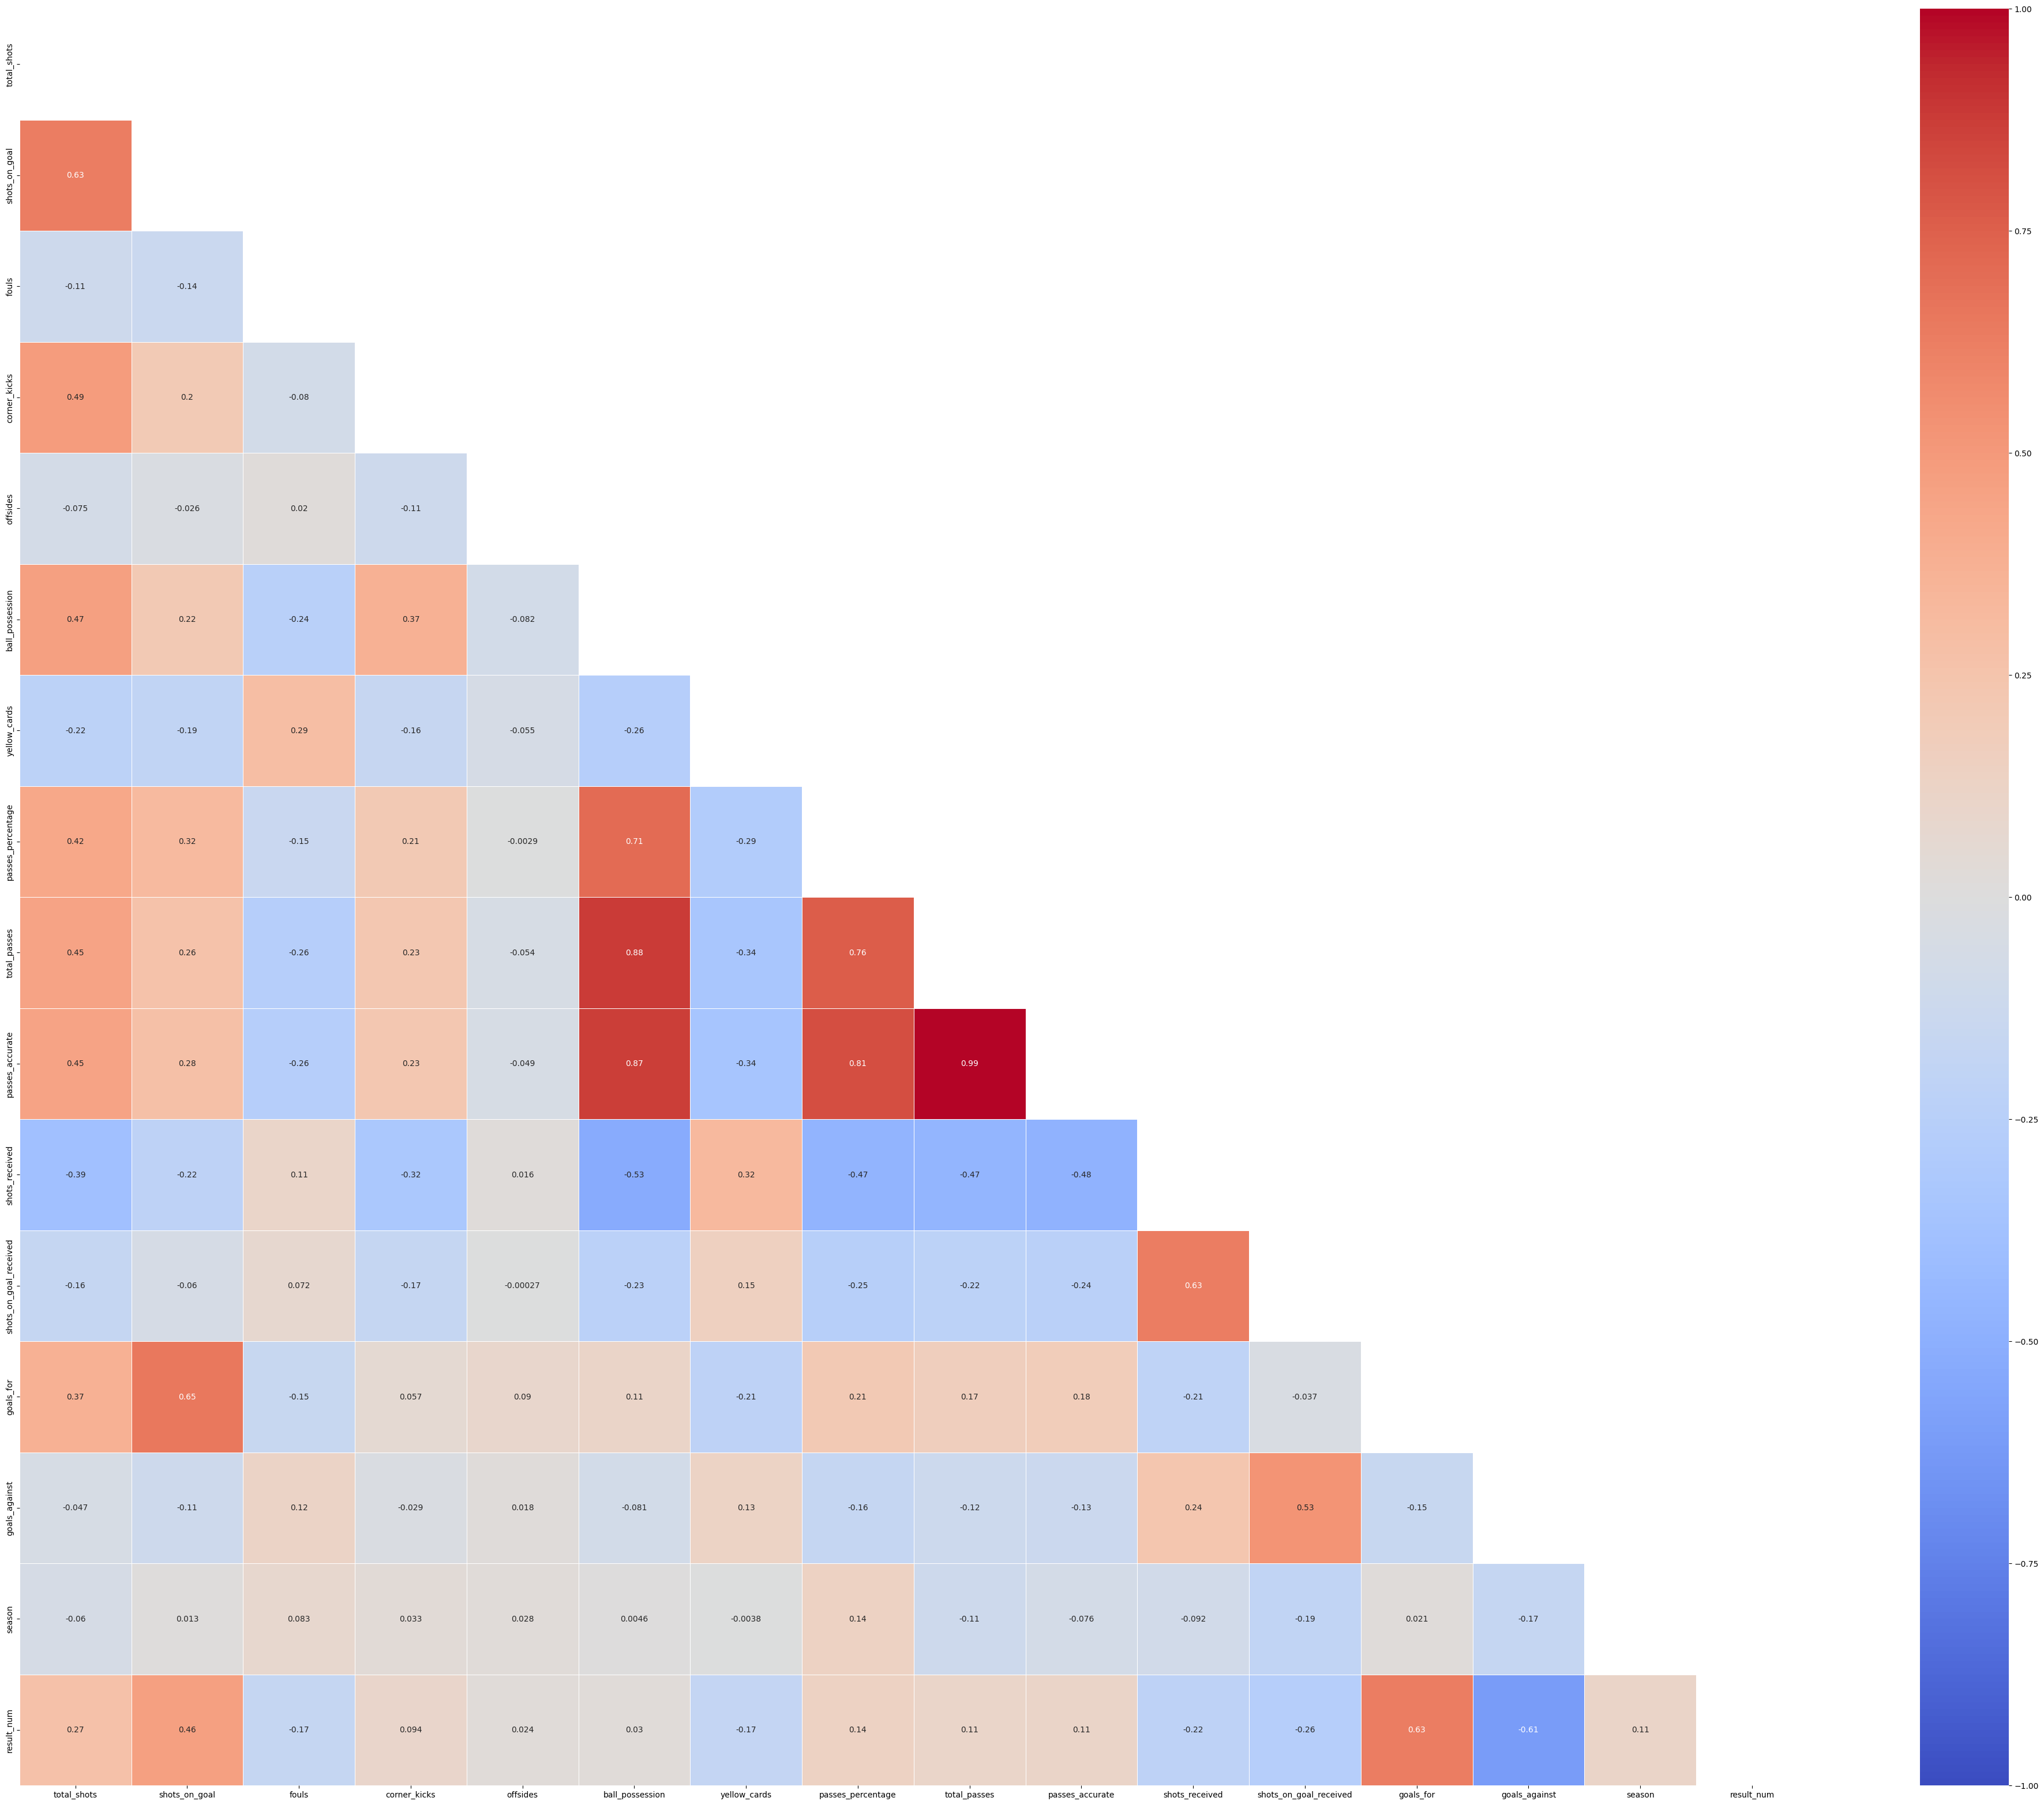

In [27]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Crear una máscara para la mitad superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(50, 40))
sns.heatmap(
    corr_matrix,
    mask=mask,       # Aplicar la máscara
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.show()

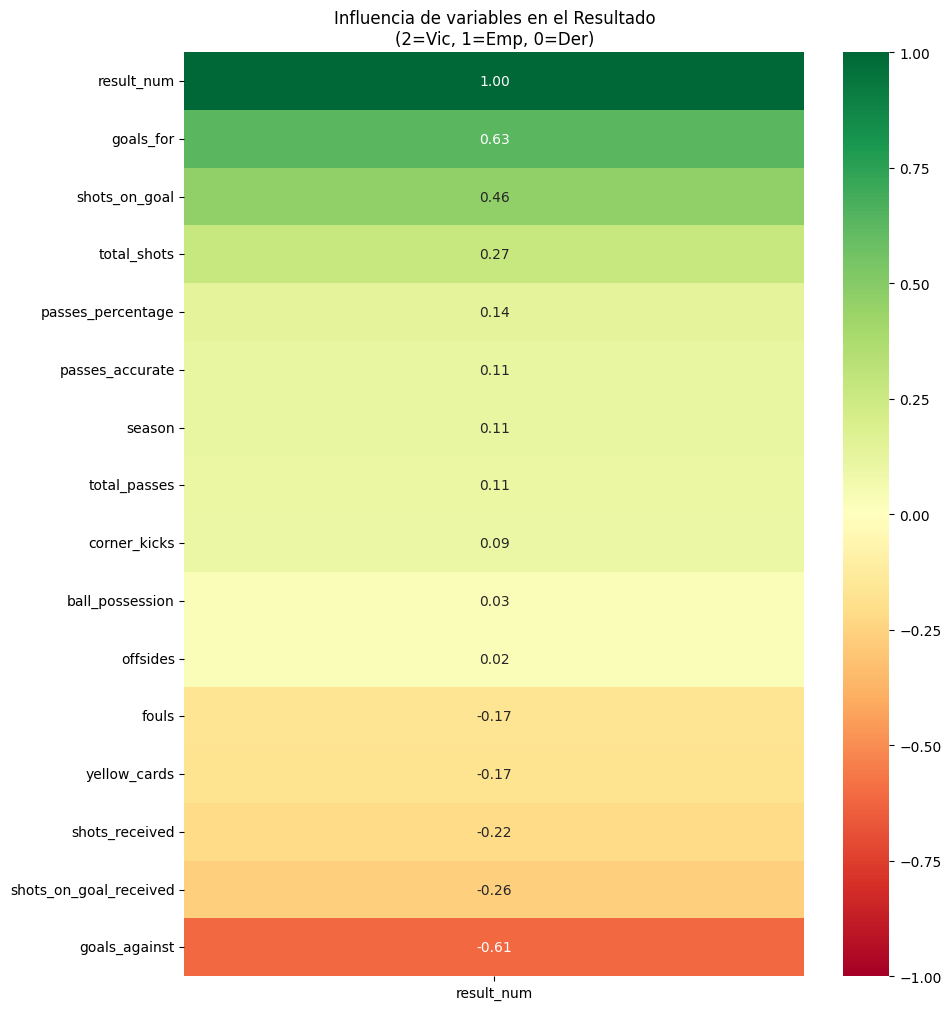

In [28]:
plt.figure(figsize=(10, 12))

# Ordenamos las correlaciones respecto a 'result_num'
res_corr = corr_matrix[['result_num']].sort_values(by='result_num', ascending=False)

sns.heatmap(
    res_corr,
    annot=True,
    cmap='RdYlGn', # Verde para correlación positiva (victoria), rojo para negativa
    vmin=-1, vmax=1,
    fmt=".2f"
)

plt.title('Influencia de variables en el Resultado\n(2=Vic, 1=Emp, 0=Der)')
plt.show()

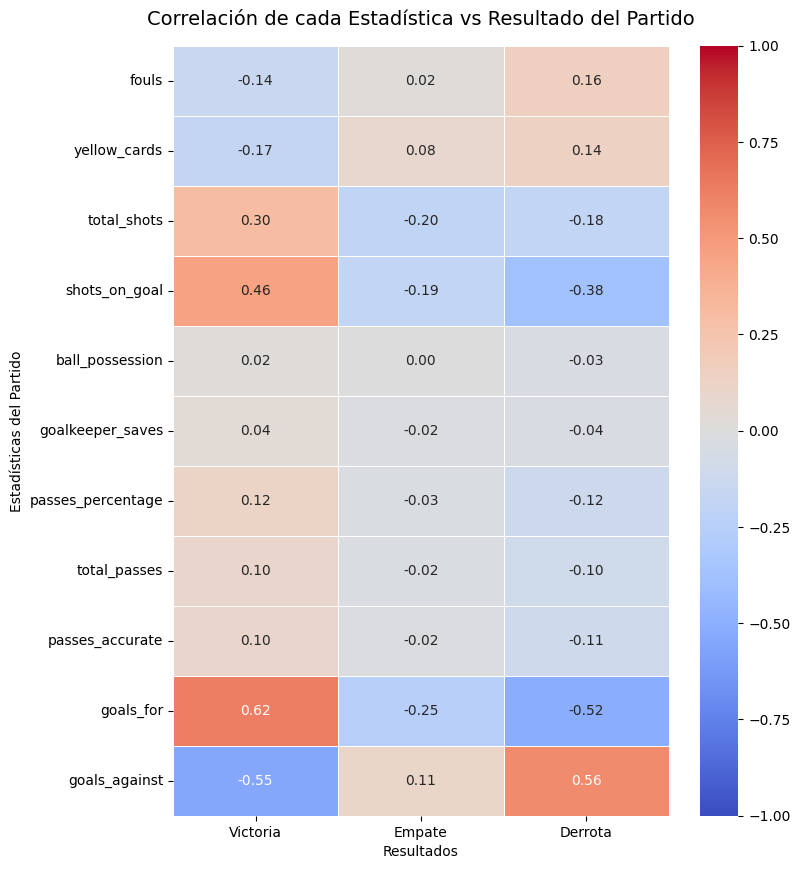

In [29]:
# 1. Creamos variables temporales binarias (1 si ocurre, 0 si no)
df_temp = df.copy()
df_temp['Victoria'] = (df_temp['result_num'] == 2).astype(int)
df_temp['Empate'] = (df_temp['result_num'] == 1).astype(int)
df_temp['Derrota'] = (df_temp['result_num'] == 0).astype(int)

# 2. Definimos las columnas de resultados y las estadísticas que ya tenías
col_resultados = ['Victoria', 'Empate', 'Derrota']
colums_analyze = ['fouls', 'yellow_cards', 'total_shots', 'shots_on_goal',
                  'ball_possession',
                  'goalkeeper_saves', 'passes_percentage', 'total_passes',
                  'passes_accurate', 'goals_for', 'goals_against']

# 3. Calculamos la correlación solo entre estadísticas y los resultados
corr_resultados = df_temp[colums_analyze + col_resultados].corr().loc[colums_analyze, col_resultados]

# 4. Graficamos el Heatmap aislado
plt.figure(figsize=(8, 10)) # Un tamaño más vertical y cómodo de leer
sns.heatmap(
    corr_resultados,
    annot=True,       # Muestra el número
    fmt=".2f",        # 2 decimales
    cmap='coolwarm',  # Azul (negativo), Rojo (positivo)
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title('Correlación de cada Estadística vs Resultado del Partido', fontsize=14, pad=15)
plt.ylabel('Estadísticas del Partido')
plt.xlabel('Resultados')
plt.show()

### **<font color='pink'>Outliers</font>**

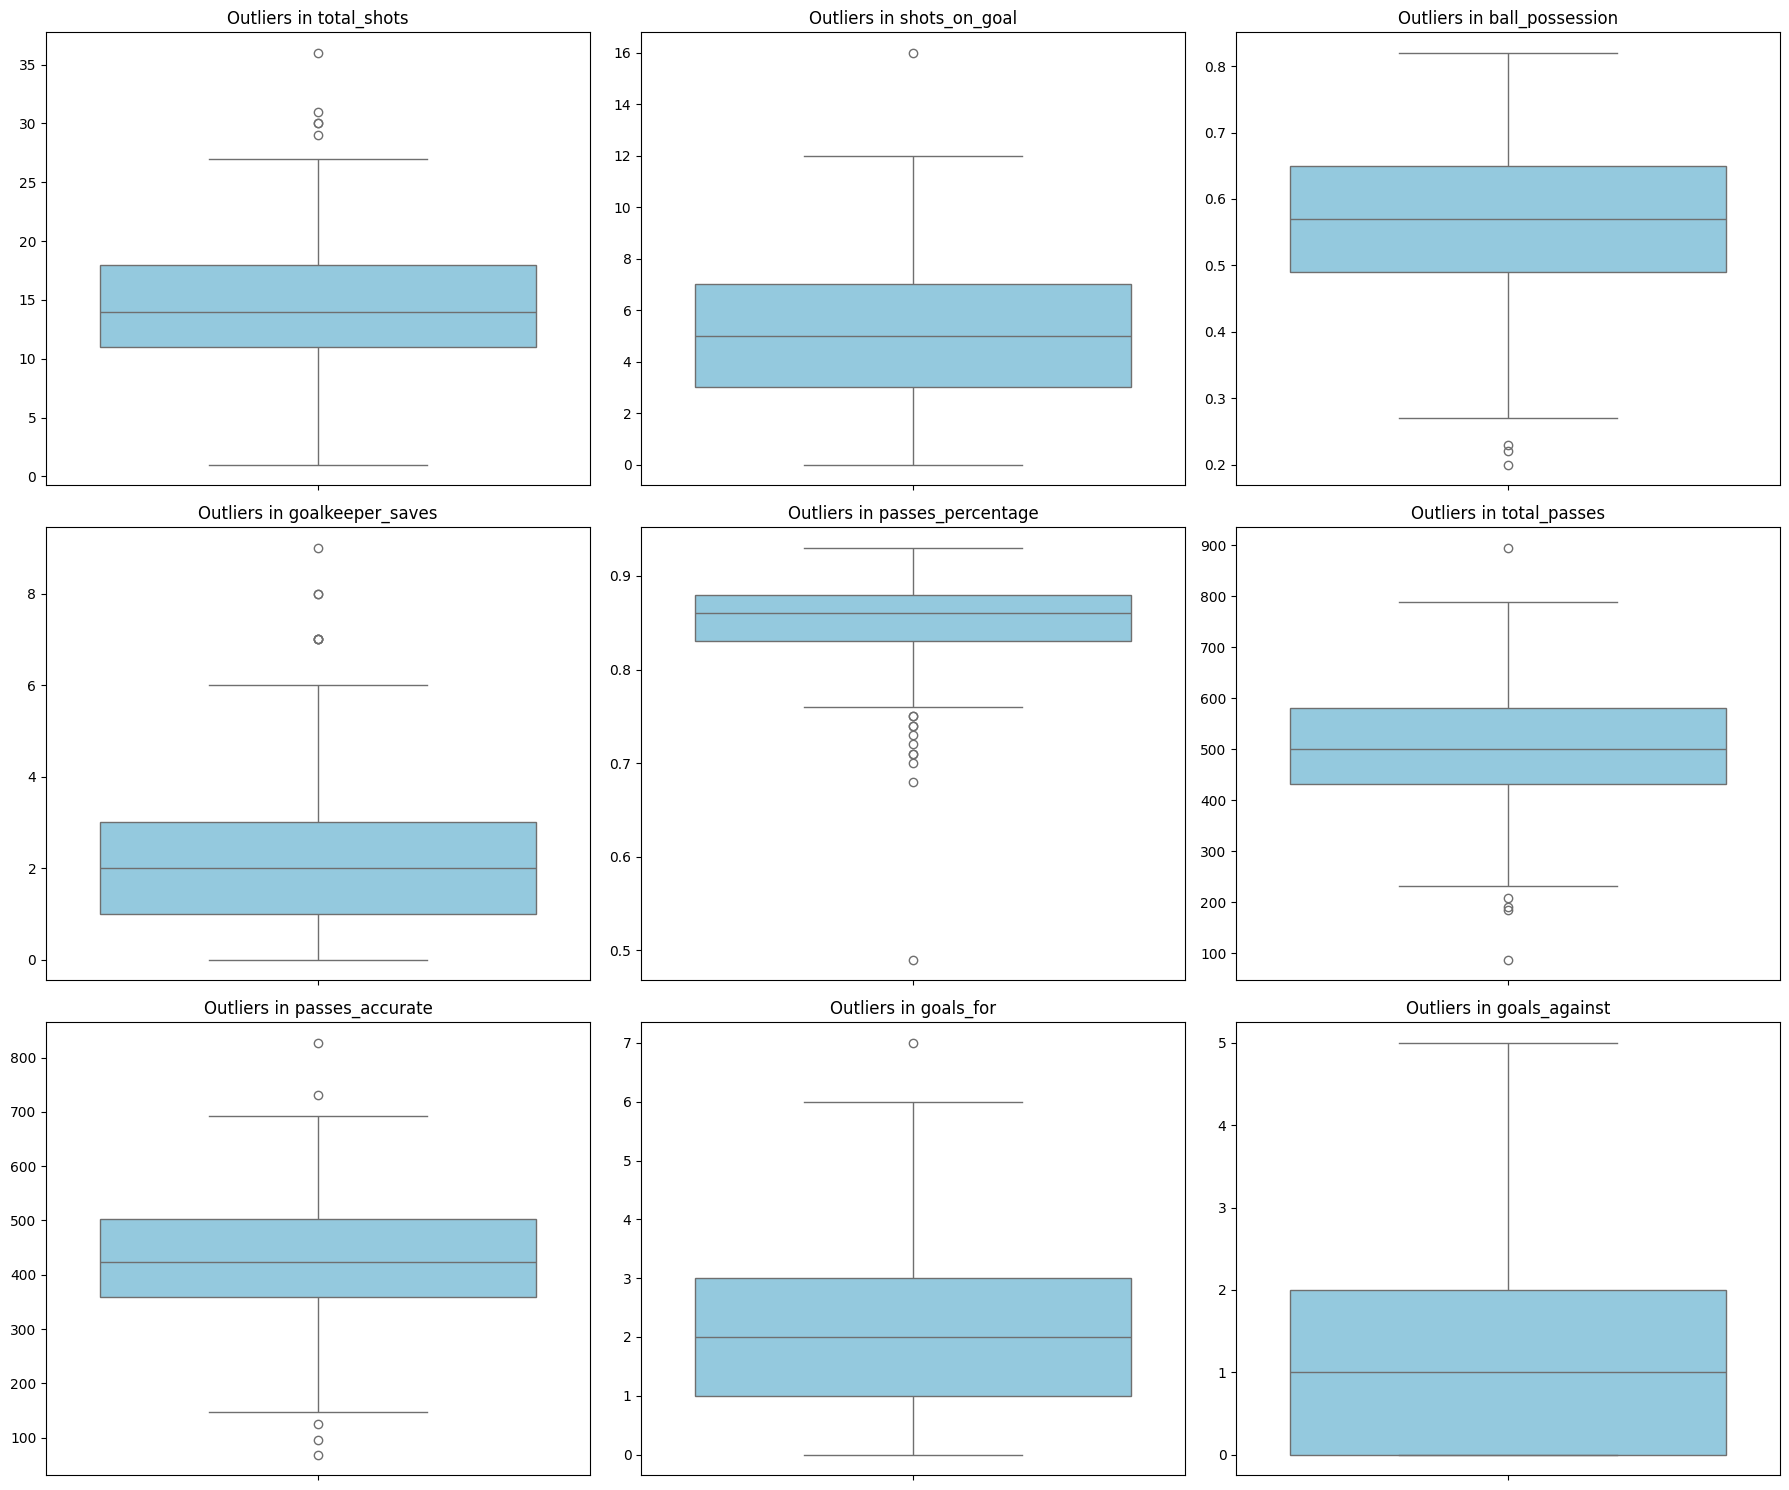

In [30]:
colums_analyze = ['total_shots', 'shots_on_goal', 'ball_possession',
                  'goalkeeper_saves', 'passes_percentage', 'total_passes',
                  'passes_accurate', 'goals_for', 'goals_against']

# Configuramos el número de columnas y calculamos las filas necesarias
cols = 3
rows = math.ceil(len(colums_analyze) / cols)

# Creamos la base del cuadro (el lienzo grande)
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten() # Aplanamos la matriz de ejes para iterar fácilmente

for i, col in enumerate(colums_analyze):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Outliers in {col}', fontsize=12)
    axes[i].set_ylabel('') # Limpiamos el nombre del eje Y para que se vea más estético

plt.tight_layout()
plt.show()

### **<font color='pink'>Victorias, Empates y Derrotas (local vs visitante)</font>**

In [31]:
match_is_home_count = df.groupby(['is_home', 'result_num']).size().unstack(fill_value=0)
match_is_home_count

/tmp/ipykernel_5740/632641939.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  match_is_home_count = df.groupby(['is_home', 'result_num']).size().unstack(fill_value=0)


result_num,0,1,2
is_home,,,
True,18,18,95
False,33,27,74


In [32]:
result = pd.crosstab(df['is_home'], df['result_num'], normalize='index')
result

result_num,0,1,2
is_home,,,
True,0.137405,0.137405,0.725191
False,0.246269,0.201493,0.552239


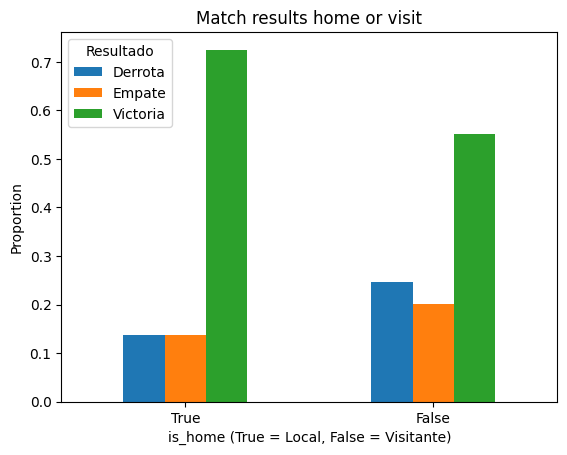

In [33]:
result.plot(kind='bar')

plt.title('Match results home or visit')
plt.xlabel('is_home (True = Local, False = Visitante)')
plt.ylabel('Proportion')
plt.legend(title='Resultado', labels=['Derrota', 'Empate', 'Victoria'], loc='upper left')
plt.xticks(rotation=0)

plt.show()

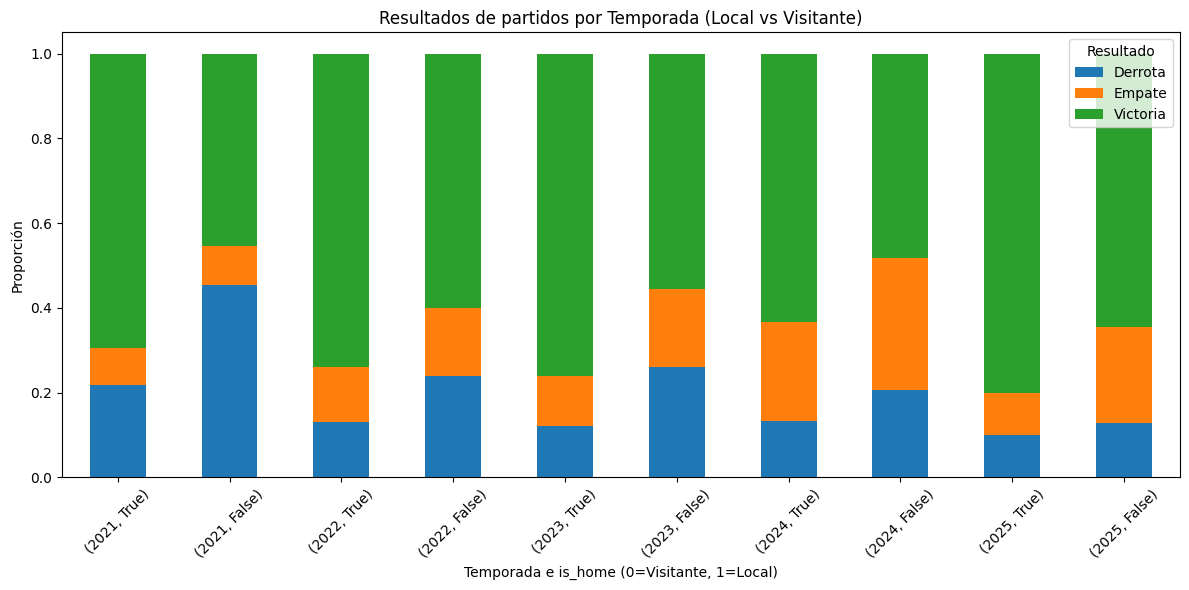

In [34]:
result_evolucion = pd.crosstab(index=[df['season'], df['is_home']],
                               columns=df['result_num'],
                               normalize='index')

ax = result_evolucion.plot(kind='bar', figsize=(12, 6), stacked=True)

plt.title('Resultados de partidos por Temporada (Local vs Visitante)')
plt.xlabel('Temporada e is_home (0=Visitante, 1=Local)')
plt.ylabel('Proporción')
plt.legend(title='Resultado', labels=['Derrota', 'Empate', 'Victoria'], loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **<font color='pink'>Histogramas</font>**

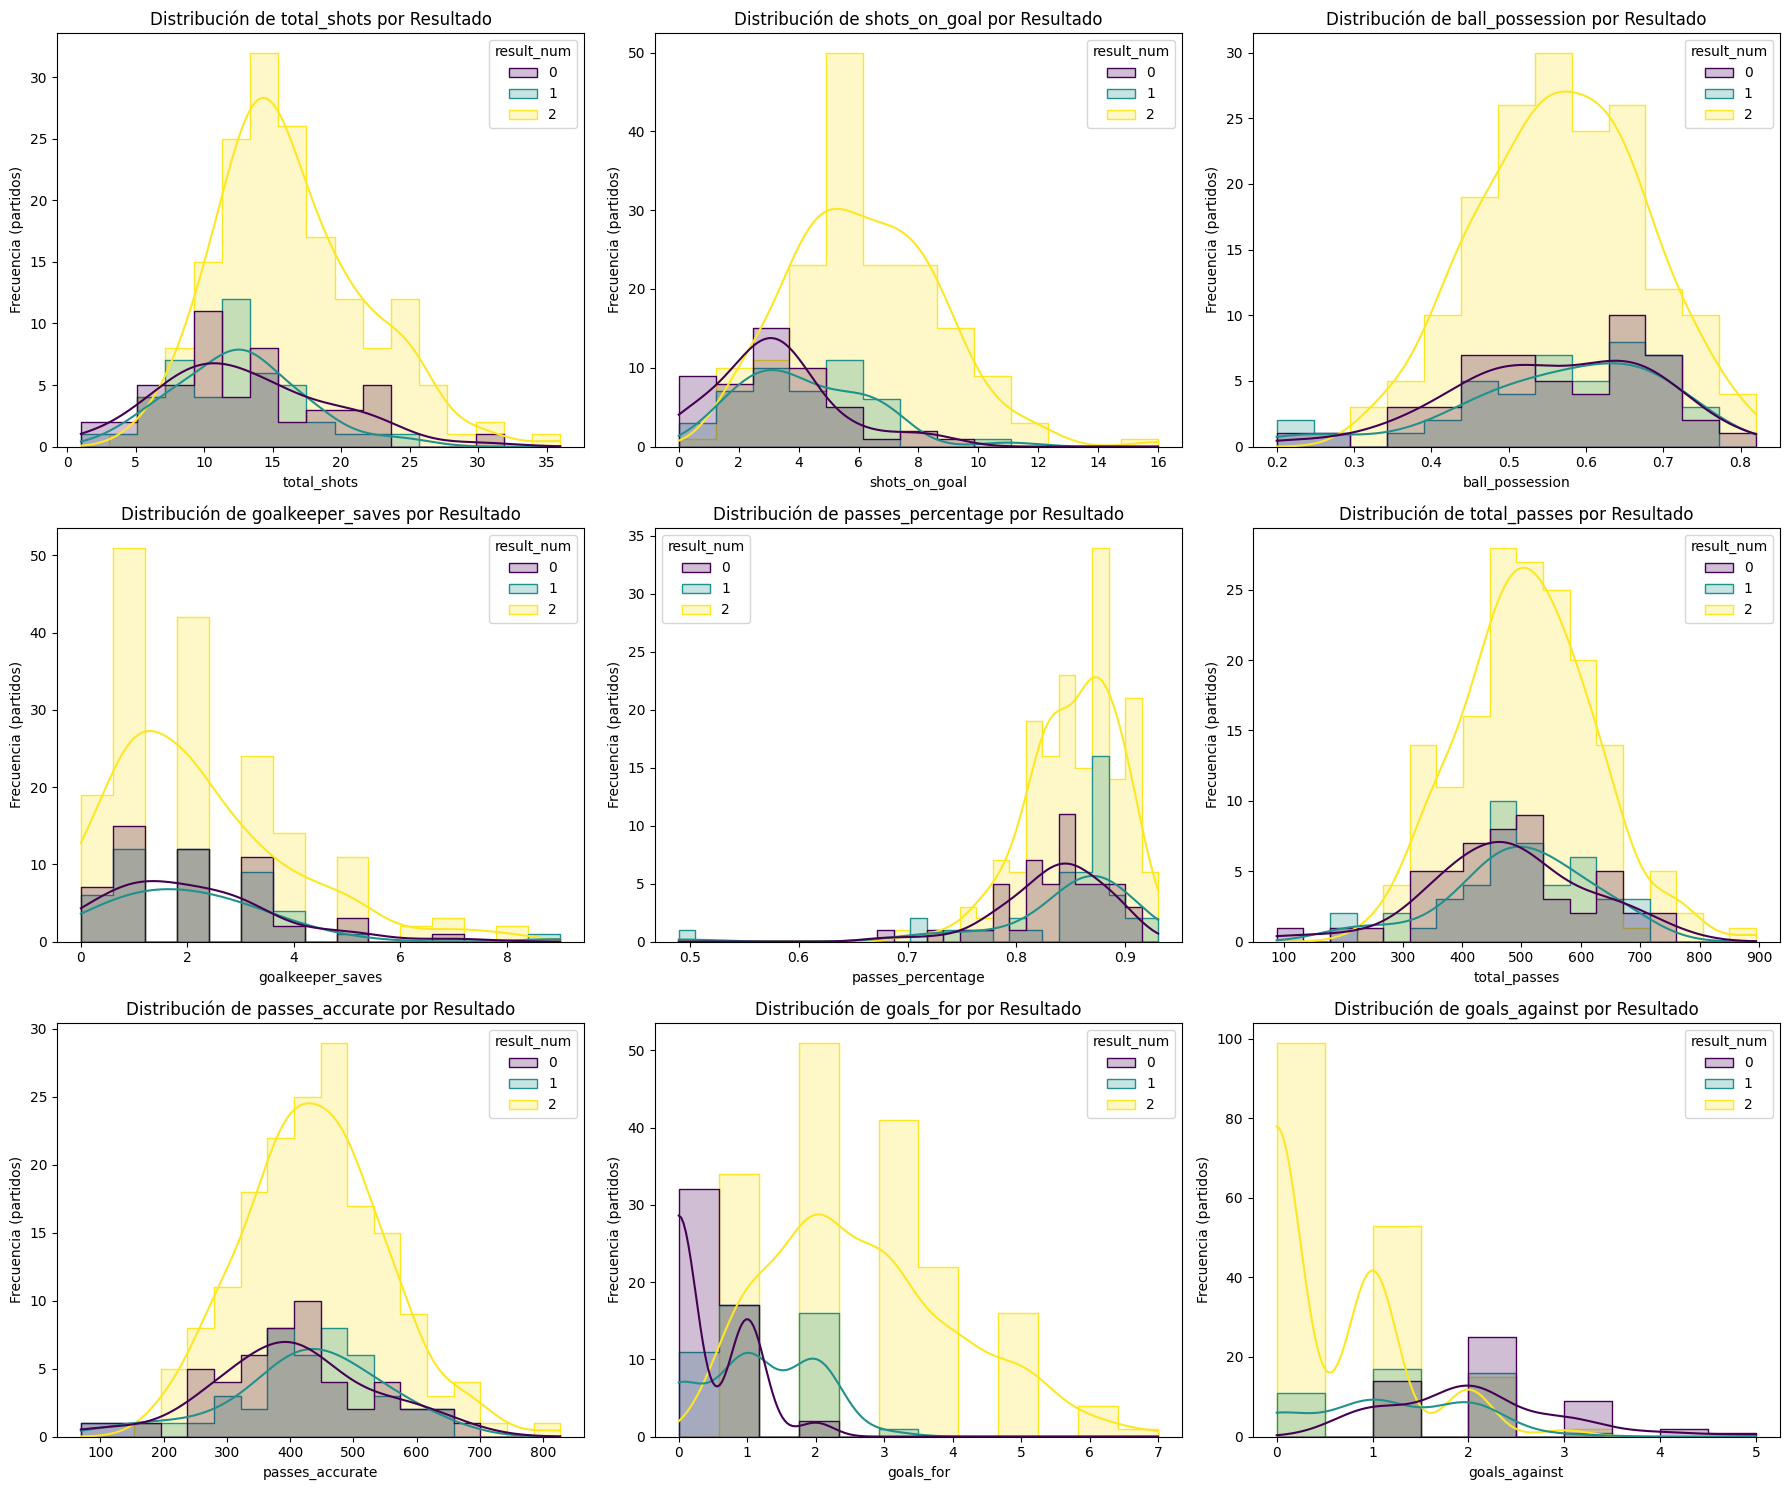

In [35]:
colums_analyze = ['total_shots', 'shots_on_goal', 'ball_possession',
                  'goalkeeper_saves', 'passes_percentage', 'total_passes',
                  'passes_accurate', 'goals_for', 'goals_against']

cols = 3
rows = math.ceil(len(colums_analyze) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, col in enumerate(colums_analyze):
    # Creamos el histograma
    # hue='result_num' separa por colores según el resultado
    # kde=True añade una línea de suavizado para ver mejor la tendencia
    sns.histplot(data=df,
                 x=col,
                 hue='result_num',
                 kde=True,
                 element="step",
                 ax=axes[i],
                 palette='viridis')

    axes[i].set_title(f'Distribución de {col} por Resultado', fontsize=12)
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Frecuencia (partidos)')

plt.tight_layout()
plt.show()

### **<font color='pink'>Valores nulos</font>**

<Axes: >

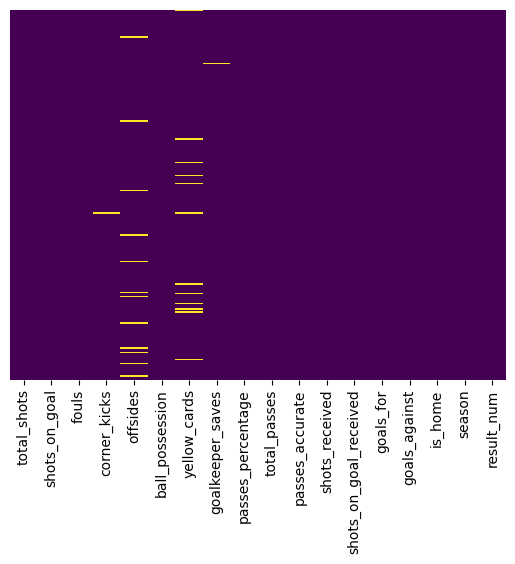

In [36]:
sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False,
            cmap='viridis')

### **<font color='green'>Preprocesamiento (Eliminar columunas con valores faltantes)</font>**

In [37]:
columns_drop = ['offsides', 'yellow_cards']

df_production = df.drop(columns_drop, axis=1)

df_production.head(2)

,total_shots,shots_on_goal,fouls,corner_kicks,ball_possession,goalkeeper_saves,passes_percentage,total_passes,passes_accurate,shots_received,shots_on_goal_received,goals_for,goals_against,is_home,season,result_num
0,22,4,8,5.0,0.65,1,0.86,568,488,8,3,0,2,False,2021,0
1,6,3,10,9.0,0.35,3,0.79,335,266,22,5,0,2,True,2021,0


In [38]:
display(df_production.isnull().sum())

,0
total_shots,0
shots_on_goal,0
fouls,0
corner_kicks,1
ball_possession,0
goalkeeper_saves,1
passes_percentage,0
total_passes,0
passes_accurate,0
shots_received,0


## 🔨 <font color=#258FE8>**Ingeniería de características**</font> (Avance 2)

### Obtener dataset de partidos (información general)

In [39]:
df_api = get_general_results_matches_all_teams()

SEASON: 2021
ID LEAGUE: 2
No. errors:  0
No. results:  218
----



ID LEAGUE: 3
No. errors:  0
No. results:  177
----



ID LEAGUE: 39
No. errors:  0
No. results:  380
----



ID LEAGUE: 45
No. errors:  0
No. results:  868
----



ID LEAGUE: 48
No. errors:  0
No. results:  93
----



ID LEAGUE: 528
No. errors:  0
No. results:  1
----



ID LEAGUE: 667
No. errors:  0
No. results:  6852
----



ID LEAGUE: 866
No. errors:  0
No. results:  1
----



ID LEAGUE: 937
No. errors:  0
No. results:  0
----



SEASON: 2022
ID LEAGUE: 2
No. errors:  0
No. results:  214
----



ID LEAGUE: 3
No. errors:  0
No. results:  175
----



ID LEAGUE: 39
No. errors:  0
No. results:  380
----



ID LEAGUE: 45
No. errors:  0
No. results:  889
----



ID LEAGUE: 48
No. errors:  0
No. results:  93
----



ID LEAGUE: 528
No. errors:  0
No. results:  1
----



ID LEAGUE: 667
No. errors:  0
No. results:  5509
----



ID LEAGUE: 866
No. errors:  0
No. results:  1
----



ID LEAGUE: 937
No. errors:  0
No. results:  1


In [40]:
df = df_api.copy()

In [41]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date').reset_index(drop=True)
display(df.shape)
display(df.head(2))

(41655, 7)

,fixture_id,season,date,home_team,away_team,home_goals,away_goals
0,738437,2021,2021-01-01 09:00:00+00:00,Sanna Khanh Hoa,Da Nang,2,3
1,738438,2021,2021-01-01 11:00:00+00:00,Binh Duong,Nam Dinh,2,1


### **<font color='orange'>ELO Ranking avanzado</font>**

#### Inicializamos a todos los equipos otorgando un valor inicial de 1,500 pts

In [42]:
teams = pd.concat([df['home_team'], df['away_team']]).unique()
elo_dictionary = {team: 1500 for team in teams}
elo_dictionary

{'Sanna Khanh Hoa': 1500,
 'Binh Duong': 1500,
 'Ho Chi Minh': 1500,
 'Sai Gon': 1500,
 'Alondras': 1500,
 'Nam Dinh': 1500,
 'Hoang Anh Gia Lai': 1500,
 'Soroksar': 1500,
 'Laredo': 1500,
 'Litex': 1500,
 'Renova': 1500,
 'Chemik Bydgoszcz': 1500,
 'Akademija Pandev': 1500,
 'Lokomotiv Sofia': 1500,
 'Śląsk Wrocław II': 1500,
 'Bytovia Bytów': 1500,
 'Pirin Blagoevgrad': 1500,
 'Sesvete': 1500,
 'Hebar 1918': 1500,
 'Belasitsa': 1500,
 'Borec': 1500,
 'Opatija': 1500,
 'Pogoń Siedlce': 1500,
 'CSM Reşiţa': 1500,
 'Drita': 1500,
 'Belasica': 1500,
 'Strumska Slava': 1500,
 'Petrolul Ploiesti': 1500,
 'Spartak Pleven': 1500,
 'Podbrezová': 1500,
 'Progresul Spartac': 1500,
 'Gyirmot SE': 1500,
 'Polonia Bytom': 1500,
 'Žilina II': 1500,
 'Olimpia Elbląg': 1500,
 'Sokół Ostróda': 1500,
 'Radomiak Radom': 1500,
 'Elana Toruń': 1500,
 'FK Rabotnicki': 1500,
 'Yambol 1915': 1500,
 'FUS Rabat': 1500,
 'Szombathelyi Haladas': 1500,
 'GKS Katowice': 1500,
 'LDU de Quito': 1500,
 'Ohrid': 1500,

#### Función para hacer un reinicio de los pts de los equipos

* Cada nueva temporada tenemos que hacer un reinicio parcial de los pts obtenidos, esto es debido a que los equipos se refuerzan o desarman, cambian de DT, compran y venden jugadores, personal, etc.

* Actualmente nos quedamos con el 0.33% de los puntos obtenidos en la campaña.

In [43]:
def reboot_elo_new_seasson(elo_dictionary):

  for team, elo in elo_dictionary.items():
    #print(team, elo)
    #elo_dictionary[team] = (elo * 0.75) + (1500 * 0.25)
    elo_dictionary[team] = (elo * 0.67) + (1500 * 0.33)

#### Función para crear la tabla ELO hasta el último partido registrado

In [44]:
# HFA = ventaja de local (Home Field Advantage)
# K = Es un valor dinámico (respecto al torneo) para darle variedad a la puntuación
K, HFA = 20, 53
test_reboot_elo_ranking = True

# Listas temporales para guardar el estado ANTES del partido
elo_home_pre = []
elo_away_pre = []

current_year = int(AVAILABLE_SEASSONS[0])

# Recorremos todos los partidos
for index, row in df.iterrows():

  if row['season'] != current_year and test_reboot_elo_ranking:
    display(f"Last year: {current_year} // Current year {row['season']}")
    current_year = row['season']
    reboot_elo_new_seasson(elo_dictionary)

  home = row['home_team']
  away = row['away_team']
  goals_h = row['home_goals']
  goals_a = row['away_goals']

  # 1. Leer el elo actual de los equipos
  elo_current_h = elo_dictionary[home]
  elo_current_a = elo_dictionary[away]


  if index == 0:
    display(home)
    display(away)
    display(f"H: {elo_current_h} // A: {elo_current_a}")

  # 2. Guardarlo para el modelo predictivo
  elo_home_pre.append(elo_current_h)
  elo_away_pre.append(elo_current_a)

  # 3. Calcular la probabilidad con la fórmula de elo
  # Agregamos +100 al local para simular la ventaja de jugar en casa (Home Field Advantage)
  E_home = 1 / (1 + 10 ** (((elo_current_a) - (elo_current_h + HFA)) / 400))
  E_away = 1 - E_home

  # 4. Determinar el resultado real
  # (1 = gana local, 0.5 = empate, 0 = gana visita)
  if goals_h > goals_a:
      S_home, S_away = 1, 0
  elif goals_h == goals_a:
      S_home, S_away = 0.5, 0.5
  else:
      S_home, S_away = 0, 1

  # 5. Multiplicar por el margen de victoria
  # Un 4-0 demuestra más superioridad que un 1-0
  # Usamos la raíz cuadrada de la diferencia para amplificar un resultado grande
  margin_goals = abs(goals_h - goals_a)
  margin_multiplier = math.sqrt(margin_goals) if margin_goals > 0 else 1.0

  # 6. Calcular los puntos ganados en el partido
  change_elo_home = K * margin_multiplier * (S_home - E_home)
  change_elo_away = K * margin_multiplier * (S_away - E_away)

  # 7. Actualizar el diccionario de los equipos con los elo
  elo_dictionary[home] = elo_current_h + change_elo_home
  elo_dictionary[away] = elo_current_a + change_elo_away

  # ¿No se debería ir actualizando el ELO respecto a cada partido?
  # 8. Añadir el elo al dataframe
  df.at[index, 'Elo_Home_Pre'] = elo_current_h
  df.at[index, 'Elo_Away_Pre'] = elo_current_a
  df.at[index, 'Elo_Diff'] = (elo_current_h - elo_current_a)

'Sanna Khanh Hoa'

'Da Nang'

'H: 1500 // A: 1500'

'Last year: 2021 // Current year 2022'

'Last year: 2022 // Current year 2021'

...

'Last year: 2025 // Current year 2026'

'Last year: 2026 // Current year 2025'

'Last year: 2025 // Current year 2026'

'Last year: 2026 // Current year 2025'

'Last year: 2025 // Current year 2026'

In [45]:
df

,fixture_id,season,date,home_team,away_team,home_goals,away_goals,Elo_Home_Pre,Elo_Away_Pre,Elo_Diff
0,738437,2021,2021-01-01 09:00:00+00:00,Sanna Khanh Hoa,Da Nang,2,3,1500.000000,1500.000000,0.000000e+00
1,738438,2021,2021-01-01 11:00:00+00:00,Binh Duong,Nam Dinh,2,1,1500.000000,1500.000000,0.000000e+00
2,738439,2021,2021-01-02 10:00:00+00:00,Ho Chi Minh,Ha Noi,2,1,1500.000000,1500.000000,0.000000e+00
3,738440,2021,2021-01-02 12:30:00+00:00,Sai Gon,Binh Dinh,1,1,1500.000000,1500.000000,0.000000e+00
4,738441,2021,2021-01-02 15:30:00+00:00,Alondras,Coruxo,0,2,1500.000000,1500.000000,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
41650,1379341,2025,2026-05-24 15:00:00+00:00,Crystal Palace,Arsenal,1,2,1497.176066,1503.948469,-6.772403e+00
41651,1379345,2025,2026-05-24 15:00:00+00:00,Nottingham Forest,Bournemouth,1,1,1500.658669,1502.099729,-1.441060e+00
41652,1546577,2026,2026-05-27 17:00:00+00:00,Medeama,Basake Holy Stars,2,1,1500.000000,1500.000000,0.000000e+00
41653,1542333,2026,2026-05-29 18:00:00+00:00,Mamelodi Sundowns,RB Leipzig,3,1,1500.000000,1500.000000,0.000000e+00


In [46]:
#Contador para ver cuántas veces gana el visitante y cuántas veces el local
favorito_local_y_gana = 0
favorito_visita_y_gana = 0
empates_totales = 0

for index, row in df.iterrows():
    # Determinamos qué pasó en la vida real
    if row['home_goals'] > row['away_goals']:
        resultado_real = '1' # Ganó Local
    elif row['home_goals'] == row['away_goals']:
        resultado_real = 'X' # Empate
    else:
        resultado_real = '2' # Ganó Visita

    # Caso A: El Local era el favorito por ELO (Elo_Diff > 0) y cumplió ganando
    if row['Elo_Diff'] > 0 and resultado_real == '1':
        favorito_local_y_gana += 1

    # Caso B: El Visitante era el favorito por ELO (Elo_Diff < 0) y rompió la localía ganando
    elif row['Elo_Diff'] < 0 and resultado_real == '2':
        favorito_visita_y_gana += 1

    # Conteo de empates reales para el contexto general
    if resultado_real == 'X':
        empates_totales += 1

total_partidos = len(df)
pct_local = (favorito_local_y_gana / total_partidos) * 100
pct_visita = (favorito_visita_y_gana / total_partidos) * 100
pct_empates = (empates_totales / total_partidos) * 100

print(f"Veces que el Local era favorito en ELO y SÍ ganó: {favorito_local_y_gana} ({pct_local:.2f}%)")
print(f"Veces que el Visitante era favorito en ELO y SÍ ganó: {favorito_visita_y_gana} ({pct_visita:.2f}%)")
print(f"Empates reales registrados en el dataset: {empates_totales} ({pct_empates:.2f}%)")



Veces que el Local era favorito en ELO y SÍ ganó: 9883 (23.73%)
Veces que el Visitante era favorito en ELO y SÍ ganó: 7598 (18.24%)
Empates reales registrados en el dataset: 8346 (20.04%)


In [47]:
#Contador para ver cuántas veces gana el visitante sin ser favorito
no_favorito_visita_y_gana = 0


for index, row in df.iterrows():
    # Determinamos qué pasó en la vida real
    if row['home_goals'] > row['away_goals']:
        resultado_real = '1' # Ganó Local
    elif row['home_goals'] == row['away_goals']:
        resultado_real = 'X' # Empate
    else:
        resultado_real = '2' # Ganó Visita

    # Caso A: El Visitante no era el favorito por ELO (Elo_Diff > 0) y rompió la localía ganando
    if row['Elo_Diff'] > 0 and resultado_real == '2':
      no_favorito_visita_y_gana += 1


total_partidos = len(df)
pct_visita = (no_favorito_visita_y_gana / total_partidos) * 100

print(f"Veces que el Visitante no era favorito en ELO y SÍ ganó: {favorito_visita_y_gana} ({pct_visita:.2f}%)")


Veces que el Visitante no era favorito en ELO y SÍ ganó: 7598 (13.96%)


#### <font color=pink>Observar el ELO ranking final</font>

In [48]:
display(pd.Series(elo_dictionary).sort_values(ascending=False).round(2).head(30))

,0
Silkeborg,1530.46
Manchester United,1514.65
Aston Villa,1514.31
Mamelodi Sundowns,1512.00
Arsenal,1510.23
Medeama,1508.49
West Ham,1508.05
Partizani,1507.31
Fulham,1506.91
Sunderland,1506.00


In [49]:
len(df)

41655

### **Standard Scaler**

In [50]:
df.head(2)

,fixture_id,season,date,home_team,away_team,home_goals,away_goals,Elo_Home_Pre,Elo_Away_Pre,Elo_Diff
0,738437,2021,2021-01-01 09:00:00+00:00,Sanna Khanh Hoa,Da Nang,2,3,1500.0,1500.0,0.0
1,738438,2021,2021-01-01 11:00:00+00:00,Binh Duong,Nam Dinh,2,1,1500.0,1500.0,0.0


In [51]:
# El número de partidos que tienen exactamente 1500
# estos partidos son los que iniciaron nuestra puntuación elo
df_test = df[df['Elo_Home_Pre'] == 1500].copy()
len(df_test)

6217

In [52]:
# Eliminamos los primeros partidos que ayudaron a inicializar
# Son los que exactamente tienen 1,500 pts
df_train = df[df['Elo_Home_Pre'] != 1500].copy()
len(df_train)

35438

In [53]:
SCALER = StandardScaler()

X_local = df_train[['Elo_Home_Pre', 'Elo_Away_Pre']]
y_local = df_train['home_goals']

X_away = df_train[['Elo_Away_Pre', 'Elo_Home_Pre']]
y_away = df_train['away_goals']

X_local_scaled = SCALER.fit_transform(X_local)
X_away_scaled = SCALER.fit_transform(X_away)


In [54]:
display(X_local_scaled)
display(X_away_scaled)

array([[-0.61227024, -0.25073676],
       [ 0.08922351, -0.74123851],
       [-0.20885741, -0.65302261],
       ...,
       [-0.37823979, -0.08252634],
       [-0.23429981, -0.1612853 ],
       [-0.26152337, -0.25073676]])

array([[-0.25073676, -0.61227024],
       [-0.74123851,  0.08922351],
       [-0.65302261, -0.20885741],
       ...,
       [-0.08252634, -0.37823979],
       [-0.1612853 , -0.23429981],
       [-0.25073676, -0.26152337]])

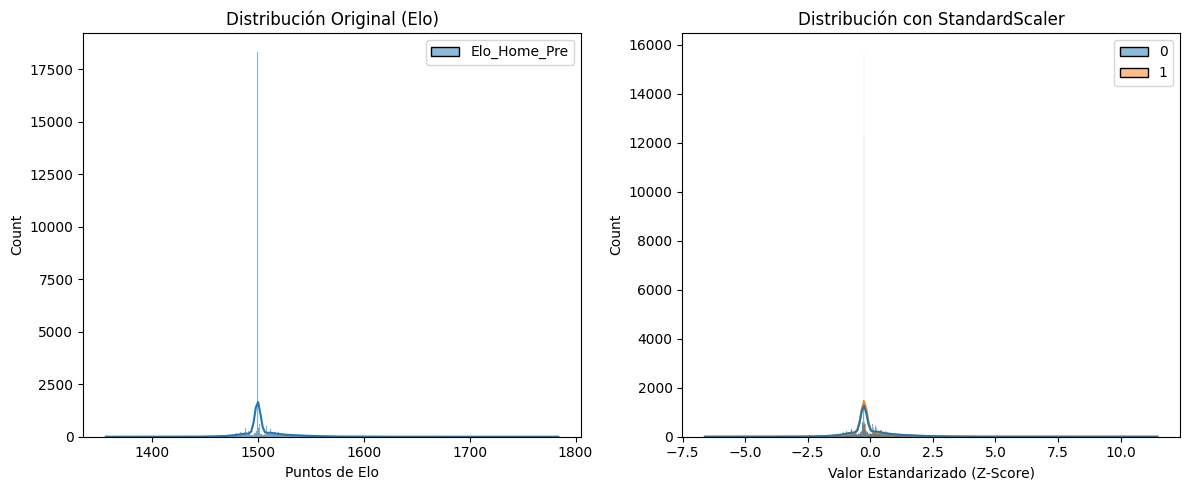

In [55]:
elo_original = df[['Elo_Home_Pre']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Antes del escalado
sns.histplot(elo_original, kde=True, color='skyblue', ax=ax1)
ax1.set_title('Distribución Original (Elo)')
ax1.set_xlabel('Puntos de Elo')

# Gráfico 2: Después del escalado
sns.histplot(X_local_scaled, kde=True, color='olive', ax=ax2)
ax2.set_title('Distribución con StandardScaler')
ax2.set_xlabel('Valor Estandarizado (Z-Score)')

plt.tight_layout()
plt.show()

## 🏁 <font color=#258FE8>**Baseline**</font> (Avance 3)

In [56]:
df_train.head(2)

,fixture_id,season,date,home_team,away_team,home_goals,away_goals,Elo_Home_Pre,Elo_Away_Pre,Elo_Diff
5,738442,2021,2021-01-03 09:00:00+00:00,Nam Dinh,Hoang Anh Gia Lai,1,1,1491.513739,1500.000000,-8.486261
6,738443,2021,2021-01-03 11:00:00+00:00,Binh Duong,Sanna Khanh Hoa,0,0,1508.486261,1488.486261,20.000000


### Train

In [57]:
# 1. PREPARACIÓN DE DATOS
# Features: Usamos el Elo de ambos para capturar la diferencia de nivel
X_local = df_train[['Elo_Home_Pre', 'Elo_Away_Pre']]
y_local = df_train['home_goals']

# Para el visitante invertimos el orden lógico para el modelo
X_visita = df_train[['Elo_Away_Pre', 'Elo_Home_Pre']]
y_visita = df_train['away_goals']

# 2. ENTRENAMIENTO DEL MODELO POISSON
modelo_local = make_pipeline(StandardScaler(), PoissonRegressor())
modelo_visita = make_pipeline(StandardScaler(), PoissonRegressor())

modelo_local.fit(X_local, y_local)
modelo_visita.fit(X_visita, y_visita)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('poissonregressor', PoissonRegressor())])

### Inference

In [58]:
# ---------------------------------------------------------
# PREDICCIÓN QUINIELA
# Equipo A vs Equipo B
# ---------------------------------------------------------
def inference_vol1(name_local, name_away):

  print(f"{name_local} vs {name_away}\n")

  elo_equipo_A, elo_equipo_B = elo_dictionary[name_local], elo_dictionary[name_away] # LOCAL / VISITANTE

  elo_diff = elo_equipo_A - elo_equipo_B

  # A. Predecir los Goles Esperados (Lambda)
  lambda_local = modelo_local.predict([[elo_equipo_A, elo_equipo_B]])[0]
  lambda_visita = modelo_visita.predict([[elo_equipo_B, elo_equipo_A]])[0]

  print(f"Goles esperados Local: {lambda_local:.2f}")
  print(f"Goles esperados Visita: {lambda_visita:.2f}\n")

  # B. Simular la Matriz de Marcadores usando la distribución de Poisson
  max_goles = 5 # Marcadores más allá de 5 goles son estadísticamente raros
  prob_victoria_local = 0
  prob_empate = 0
  prob_victoria_visita = 0

  for goles_L in range(max_goles + 1):
      for goles_V in range(max_goles + 1):
          # La probabilidad de un marcador exacto (ej. 2-1) es la multiplicación de las probabilidades independientes de los goles de cada equipo
          prob_marcador = poisson.pmf(goles_L, lambda_local) * poisson.pmf(goles_V, lambda_visita)

          # Clasificar la probabilidad en la cubeta correcta para la quiniela
          if goles_L > goles_V:
              prob_victoria_local += prob_marcador
          elif goles_L == goles_V:
              prob_empate += prob_marcador
          else:
              prob_victoria_visita += prob_marcador


  # AJUSTE MANUAL DE EMPATES (Heurística tipo Dixon-Coles)

  # 1. Definir cuándo aplica el ajuste (ej. si la diferencia de Elo es menor a 200 puntos)
  umbral_elo_parejo = 200
  empuje_empate = 0.04 # Le vamos a sumar 4% al empate

  if abs(elo_diff) < umbral_elo_parejo:
      # Aumentamos el empate
      prob_empate += empuje_empate

      # Calculamos cuánto espacio queda para repartir entre Local y Visita
      espacio_restante = 1.0 - prob_empate

      # ¿Cuánto sumaban las victorias originales?
      suma_victorias_original = prob_victoria_local + prob_victoria_visita

      # Recalculamos las victorias proporcionalmente al espacio que queda
      prob_victoria_local = (prob_victoria_local / suma_victorias_original) * espacio_restante
      prob_victoria_visita = (prob_victoria_visita / suma_victorias_original) * espacio_restante

  # ----------------------------------------------------------------

  print("--- PRONÓSTICO PARA LA QUINIELA ---")
  print(f"Diff {elo_diff}")
  print(f"Probabilidad Local (1): {prob_victoria_local * 100:.1f}%")
  print(f"Probabilidad Empate (X): {prob_empate * 100:.1f}%")
  print(f"Probabilidad Visita (2): {prob_victoria_visita * 100:.1f}%\n")
  #----------------------------------------------------------------
  # Para poder pasar al cálculo de accuracy, guardamos la decisión del modelo:
  # REGLA 1: SI EL VISITANTE TIENE MEJOR ELO Y SU PROBABILIDAD SUPERA EL UMBRAL DEFINIDO
  # Si el visitante es superior en ELO y la diferencia de probabilidades es menor a 0.22,
  # asumimos que tiene los argumentos deportivos para romper la localía.
  dif_prob = prob_victoria_local - prob_victoria_visita

  #Regla 1, empate si la diferencia de probabilidad es muy corta entre 7.21% y 14% que es el mínimo de diferencia del dataset
  if 0.0721 <= dif_prob <= 0.14:
    resultado_predicho = "X"

  #Regla 2, cuando ELO del visitante es mayor al local y la diferencia de probabilidades es menor a 22%
  elif elo_equipo_B > elo_equipo_A and dif_prob < 0.22:
      resultado_predicho = "2" # Predicción formal: Victoria Visitante

  #Regla 3, cuando la probabilidad de victoria es mayor para el visitante
  elif prob_victoria_visita > prob_victoria_local:
      resultado_predicho = "2" # Predicción formal: Victoria Visitante

  # REGLA 4: CONDICIÓN COMPLEMENTARIA PARA EL LOCAL
  # Si no se cumple lo anterior, pero el local mantiene la ventaja probabilística tradicional,
  elif prob_victoria_local > prob_victoria_visita:
      resultado_predicho = "1" # Predicción formal: Victoria Local

  # REGLA 5: CASOS DE EXCEPCIÓN por defecto
  else:
      resultado_predicho = "1"

  return resultado_predicho

### Testing

In [59]:
print(pd.Series(elo_dictionary).sort_values(ascending=False).round(2).head(25))

Silkeborg                   1530.46
Manchester United           1514.65
Aston Villa                 1514.31
Mamelodi Sundowns           1512.00
Arsenal                     1510.23
Medeama                     1508.49
West Ham                    1508.05
Partizani                   1507.31
Fulham                      1506.91
Sunderland                  1506.00
Tottenham                   1505.31
Borussia Mönchengladbach    1504.64
Eintracht Frankfurt         1502.98
Bournemouth                 1502.39
Brentford                   1500.64
Paris Saint Germain         1500.33
Rapid Wien II               1500.22
Francs Borains              1500.22
Metz                        1500.06
SKRA Częstochowa            1500.04
Twente                      1500.02
AS Marsa                    1500.01
The Strongest               1500.01
Tvååker                     1500.01
Honka                       1500.01
dtype: float64


In [60]:
print(pd.Series(elo_dictionary).sort_values(ascending=False).round(2).tail(25))

SC Braga             1499.79
Leobendorf           1499.78
Southampton          1499.78
SV Sandhausen        1499.77
Seraing United       1499.73
Bayern München       1499.71
Wolves               1499.53
Nottingham Forest    1499.45
Atletico Madrid      1499.43
Liverpool            1498.09
Burnley              1497.45
RW Frankfurt         1497.24
Manchester City      1495.39
Spelle-Venhaus       1495.36
SC Freiburg          1494.32
Chelsea              1494.11
Newcastle            1493.07
Everton              1492.98
Vora                 1492.69
Basake Holy Stars    1491.51
Leeds                1491.19
Crystal Palace       1490.52
RB Leipzig           1488.00
Brighton             1486.55
Silkeborg KFUM       1469.54
dtype: float64


In [61]:
name_local = "Arsenal"
name_away = "Aston Villa"

print(elo_dictionary[name_local])
print(elo_dictionary[name_away])

inference_vol1(name_local, name_away)

1510.231710549744
1514.3077772279034
Arsenal vs Aston Villa

Goles esperados Local: 1.81
Goles esperados Visita: 1.43

--- PRONÓSTICO PARA LA QUINIELA ---
Diff -4.07606667815935
Probabilidad Local (1): 43.9%
Probabilidad Empate (X): 26.9%
Probabilidad Visita (2): 29.2%



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'2'

### Evaluation Metrics

In [62]:
# import numpy as np

# # Listas para almacenar las diferencias encontradas
# lista_diferencias = []
# ejemplos_impresos = 0

# print("=== INICIANDO AUDITORÍA DE DIFERENCIAS DE PROBABILIDAD ===")

# # NOTA: Asegúrate de que 'df_test' o tu bucle use los nombres reales de tus columnas
# for index, row in df.iterrows():
#     name_local = row['home_team']  # Cambia por el nombre real de tu columna local
#     name_away = row['away_team']  # Cambia por el nombre real de tu columna visitante

#     if name_local in elo_dictionary and name_away in elo_dictionary:
#         elo_equipo_A = elo_dictionary[name_local]
#         elo_equipo_B = elo_dictionary[name_away]

#         # Predecir tasas Lambda
#         lambda_local = modelo_local.predict([[elo_equipo_A, elo_equipo_B]])[0]
#         lambda_visita = modelo_visita.predict([[elo_equipo_B, elo_equipo_A]])[0]

#         # Simular Poisson
#         prob_victoria_local = 0
#         prob_empate = 0
#         prob_victoria_visita = 0
#         max_goles = 5

#         for goles_L in range(max_goles + 1):
#             for goles_V in range(max_goles + 1):
#                 prob_marcador = poisson.pmf(goles_L, lambda_local) * poisson.pmf(goles_V, lambda_visita)
#                 if goles_L > goles_V:
#                     prob_victoria_local += prob_marcador
#                 elif goles_L == goles_V:
#                     prob_empate += prob_marcador
#                 else:
#                     prob_victoria_visita += prob_marcador

#         # Aplicar el ajuste original de empates de Mateo
#         elo_diff = elo_equipo_A - elo_equipo_B
#         if abs(elo_diff) < 200:
#             prob_empate += 0.04
#             espacio_restante = 1.0 - prob_empate
#             suma_victorias_original = prob_victoria_local + prob_victoria_visita
#             prob_victoria_local = (prob_victoria_local / suma_victorias_original) * espacio_restante
#             prob_victoria_visita = (prob_victoria_visita / suma_victorias_original) * espacio_restante

#         # Calcular la diferencia neta
#         dif_prob = prob_victoria_local - prob_victoria_visita
#         lista_diferencias.append(dif_prob)


# # Convertir a array de numpy para estadísticas globales
# lista_diferencias = np.array(lista_diferencias)

# print("\n=== REPORTE DE DISTRIBUCIÓN DE FRONTERAS ===")
# print(f"Partidos con diferencia <= 5%: {np.sum(abs(lista_diferencias) <= 0.05)}")
# print(f"Partidos con diferencia <= 10%: {np.sum(abs(lista_diferencias) <= 0.10)}")
# print(f"Partidos con diferencia <= 15%: {np.sum(abs(lista_diferencias) <= 0.15)}")
# print(f"Partidos con diferencia <= 20%: {np.sum(abs(lista_diferencias) <= 0.20)}")
# print(f"Diferencia mínima absoluta en todo el dataset: {abs(lista_diferencias).min()*100:.2f}%")
# print(f"Diferencia promedio en todo el dataset: {lista_diferencias.mean()*100:.2f}%")

In [63]:
warnings.filterwarnings("ignore")

y_true = []
y_pred = []
exitos = 0
omitidos = 0

# Evaluamos uno a uno los 41,641 partidos del DataFrame
for index, row in df.iterrows():
    local = row['home_team']
    visita = row['away_team']

    # 1. Validar que ambos equipos existan en las llaves del elo_dictionary
    if local not in elo_dictionary or visita not in elo_dictionary:
        omitidos += 1
        continue

    # 2. Determinar la etiqueta REAL del partido (Ground Truth)
    if row['home_goals'] > row['away_goals']:
        real = '1'  # Local
    elif row['home_goals'] == row['away_goals']:
        real = 'X'  # Empate
    else:
        real = '2'  # Visita

    try:
        # 3. Forzar a que la salida de texto no se trabe en consolas masivas (Silenciado dinámico)
        import sys, os
        actual_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

        # 4. Llamamos a la función inference_vol1
        prediccion = inference_vol1(local, visita)

        # Restauramos canal de texto
        sys.stdout = actual_stdout

        if prediccion is not None:
            y_true.append(real)
            y_pred.append(prediccion)
            exitos += 1

            # Control de avance visual
            if exitos % 5000 == 0:
                print(f"-> {exitos} partidos analizados con éxito...")
    except Exception as e:
        sys.stdout = actual_stdout
        errores_conteo += 1
        continue

print("\n=== PROCESAMIENTO FINALIZADO ===")
print(f"Partidos evaluados con éxito: {exitos}")
print(f"Partidos omitidos por ausencia en diccionario: {omitidos}\n")



-> 5000 partidos analizados con éxito...
-> 10000 partidos analizados con éxito...
-> 15000 partidos analizados con éxito...
-> 20000 partidos analizados con éxito...
-> 25000 partidos analizados con éxito...
-> 30000 partidos analizados con éxito...
-> 35000 partidos analizados con éxito...
-> 40000 partidos analizados con éxito...

=== PROCESAMIENTO FINALIZADO ===
Partidos evaluados con éxito: 41655
Partidos omitidos por ausencia en diccionario: 0



Accuracy Global en Test: 46.31%

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

   Local (1)       0.49      0.73      0.59     18841
  Empate (X)       0.23      0.02      0.04      8346
  Visita (2)       0.41      0.37      0.39     14468

    accuracy                           0.46     41655
   macro avg       0.38      0.37      0.34     41655
weighted avg       0.41      0.46      0.41     41655



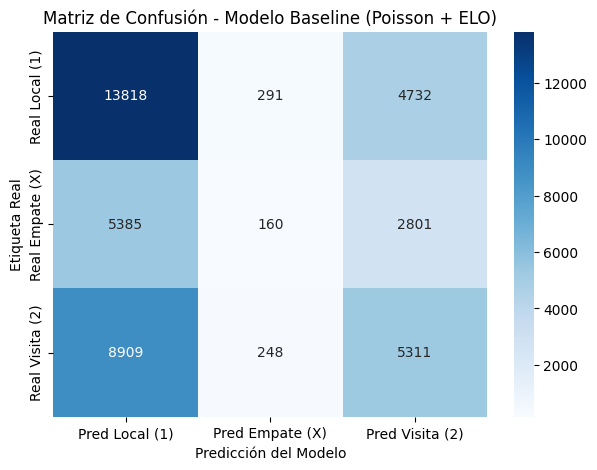

In [64]:
# CÁLCULO DE MÉTRICAS Y GRÁFICA DE LA MATRIZ DE CONFUSIÓN

if len(y_true) > 0:
    accuracy_test = accuracy_score(y_true, y_pred)
    matriz_conf = confusion_matrix(y_true, y_pred, labels=['1', 'X', '2'])
    reporte = classification_report(
        y_true, y_pred,
        labels=['1', 'X', '2'],
        target_names=['Local (1)', 'Empate (X)', 'Visita (2)'],
        zero_division=0
    )

    print(f"Accuracy Global en Test: {accuracy_test * 100:.2f}%\n")
    print("=== REPORTE DE CLASIFICACIÓN ===")
    print(reporte)

    # Dibujar la matriz de confusión gráfica
    plt.figure(figsize=(7, 5))
    sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Local (1)', 'Pred Empate (X)', 'Pred Visita (2)'],
                yticklabels=['Real Local (1)', 'Real Empate (X)', 'Real Visita (2)'])
    plt.title("Matriz de Confusión - Modelo Baseline (Poisson + ELO)")
    plt.ylabel("Etiqueta Real")
    plt.xlabel("Predicción del Modelo")
    plt.show()
else:
    print("Asegúrate de correr las celdas donde entrenas 'modelo_local' y 'modelo_visita'.")

### Modelos Alternativos

In [65]:
warnings.filterwarnings("ignore")

# Filtramos de golpe los partidos que no están en el diccionario de ELO
partidos_validos = []

for index, row in df.iterrows():
    local = row['home_team']
    visita = row['away_team']
    if local in elo_dictionary and visita in elo_dictionary:
        # Determinamos la etiqueta REAL (Ground Truth)
        if row['home_goals'] > row['away_goals']:
            real = '1'
        elif row['home_goals'] == row['away_goals']:
            real = 'X'
        else:
            real = '2'

        partidos_validos.append({
            'home_elo': elo_dictionary[local],
            'away_elo': elo_dictionary[visita],
            'elo_diff': elo_dictionary[local] - elo_dictionary[visita],
            'target': real
        })

In [66]:
# Creamos el DataFrame limpio optimizado
df_ml = pd.DataFrame(partidos_validos)
df_ml.head()

,home_elo,away_elo,elo_diff,target
0,1500.0,1500.0,4.547474e-13,2
1,1500.0,1500.0,0.000000e+00,1
2,1500.0,1500.0,-4.547474e-13,1
3,1500.0,1500.0,0.000000e+00,X
4,1500.0,1500.0,-4.547474e-13,2


In [67]:
# Limpiamos el residuo numérico flotante redondeando a 2 decimales
df_ml['elo_diff'] = df_ml['elo_diff'].round(2)
df_ml.head()

,home_elo,away_elo,elo_diff,target
0,1500.0,1500.0,0.0,2
1,1500.0,1500.0,0.0,1
2,1500.0,1500.0,-0.0,1
3,1500.0,1500.0,0.0,X
4,1500.0,1500.0,-0.0,2


In [68]:
# definimos las características
features = ['home_elo', 'away_elo', 'elo_diff']

X = df_ml[features]
y = df_ml['target']

In [69]:
# Volvemos a partir y escalar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
print(f"Partidos totales para ML: {df_ml.shape[0]}")
print(f"Omitidos originalmente: {len(df) - df_ml.shape[0]}\n")

Partidos totales para ML: 41655
Omitidos originalmente: 0



In [71]:
#Definir los modelos a usar
modelos = {
    "Regresión Logística": LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Máquina de Vector de Soporte (SVC)": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(),
    "Naive Bayes Gaussiano": GaussianNB(),
    "Perceptrón Multicapa (MLP)": MLPClassifier(max_iter=300, random_state=42)
}

In [72]:
reporte_resultados = []

print("=== ENTRENANDO LOS MODELOS ===")
print(f"Accuracy en modelo baseline: {accuracy_test * 100:.2f}%\n")
for nombre, modelo in modelos.items():
    # Entrenamos con el 80% de los datos
    modelo.fit(X_train_scaled, y_train)

    # Predecimos el 20% restante (Vectorizado)
    preds = modelo.predict(X_test_scaled)

    # Calculamos métricas de calidad
    acc = accuracy_score(y_test, preds)
    acc_pcg = acc * 100
    f1_macro = f1_score(y_test, preds, average='macro')

    reporte_resultados.append({
        "Algoritmo": nombre,
        "Accuracy Global": acc_pcg,
        "F1-Score (Macro)": f1_macro
    })
    print(f"-> {nombre} evaluado exitosamente...")

# Presentamos la tabla comparativa
df_comparativo = pd.DataFrame(reporte_resultados).sort_values(by="Accuracy Global", ascending=False)
print("\n=== TABLA COMPARATIVA DE RENDIMIENTO ===")
print(df_comparativo.to_string(index=False))

=== ENTRENANDO LOS MODELOS ===
Accuracy en modelo baseline: 46.31%

-> Regresión Logística evaluado exitosamente...
-> Árbol de Decisión evaluado exitosamente...
-> Random Forest evaluado exitosamente...
-> AdaBoost evaluado exitosamente...
-> Máquina de Vector de Soporte (SVC) evaluado exitosamente...
-> K-Nearest Neighbors (KNN) evaluado exitosamente...
-> Naive Bayes Gaussiano evaluado exitosamente...
-> Perceptrón Multicapa (MLP) evaluado exitosamente...

=== TABLA COMPARATIVA DE RENDIMIENTO ===
                         Algoritmo  Accuracy Global  F1-Score (Macro)
         K-Nearest Neighbors (KNN)        49.549874          0.355980
                          AdaBoost        45.960869          0.235745
Máquina de Vector de Soporte (SVC)        45.564758          0.234309
        Perceptrón Multicapa (MLP)        45.528748          0.230971
                 Árbol de Decisión        45.504741          0.276889
             Naive Bayes Gaussiano        45.504741          0.234262
     

In [73]:
# Selección de los Dos Mejores Modelos Individuales

top_3_acc = df_comparativo['Algoritmo'].head(3).tolist()
print(f"\nLos dos mejores modelos seleccionados para ajuste fino son: {top_3_acc} comparado con que el modelo baseline dio un accuracy de {accuracy_test * 100:.2f}%\n")


Los dos mejores modelos seleccionados para ajuste fino son: ['K-Nearest Neighbors (KNN)', 'AdaBoost', 'Máquina de Vector de Soporte (SVC)'] comparado con que el modelo baseline dio un accuracy de 46.31%



In [74]:
print("\n[Optimización] Ajustando SVC...")
# Acotamos la malla al espacio más probable para datos estructurados de ELO
param_grid_svc = {
    'C': [0.1, 1.0, 5.0],
    'kernel': ['rbf'] #
}
grid_svc = GridSearchCV(
    estimator=SVC(probability=False, random_state=42),
    param_grid=param_grid_svc,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_svc.fit(X_train_scaled, y_train)
best_svc = grid_svc.best_estimator_
print(f"Mejores parámetros SVC: {grid_svc.best_params_}")
print(f"Nuevo Accuracy en Test: {accuracy_score(y_test, best_svc.predict(X_test_scaled))*100:.2f}%")


[Optimización] Ajustando SVC...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Mejores parámetros SVC: {'C': 5.0, 'kernel': 'rbf'}
Nuevo Accuracy en Test: 45.59%


In [75]:
print("Configurando el modelo final SVC entrenado...")
mejores_params = grid_svc.best_params_
best_model_svc = SVC(C=mejores_params['C'], kernel=mejores_params['kernel'], probability=True, random_state=42)
best_model_svc.fit(X_train_scaled, y_train)

# Evaluamos
preds_svc = best_model_svc.predict(X_test_scaled)
print(f"Nuevo Accuracy de SVC en Test: {accuracy_score(y_test, preds_svc)*100:.2f}%")

print("\n=== REPORTE DE CLASIFICACIÓN (SVC OPTIMIZADO) ===")
print(classification_report(y_test, preds_svc))

Configurando el modelo final SVC entrenado...
Nuevo Accuracy de SVC en Test: 45.59%

=== REPORTE DE CLASIFICACIÓN (SVC OPTIMIZADO) ===
              precision    recall  f1-score   support

           1       0.46      0.97      0.62      3768
           2       0.48      0.04      0.07      2894
           X       0.32      0.00      0.01      1669

    accuracy                           0.46      8331
   macro avg       0.42      0.34      0.23      8331
weighted avg       0.44      0.46      0.31      8331



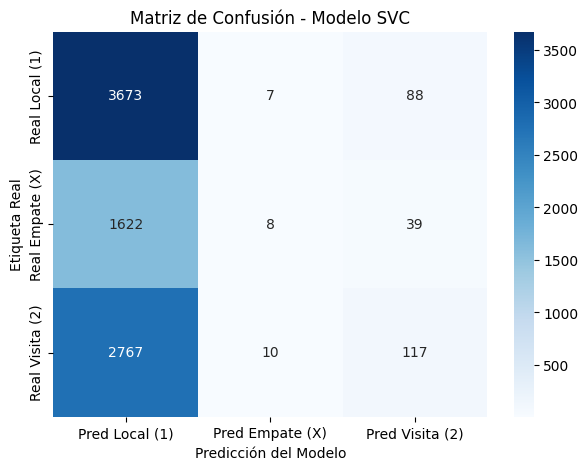

In [76]:
matriz_conf_svc = confusion_matrix(y_test, preds_svc, labels=['1', 'X', '2'])
# Dibujar la matriz de confusión gráfica
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_conf_svc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Local (1)', 'Pred Empate (X)', 'Pred Visita (2)'],
            yticklabels=['Real Local (1)', 'Real Empate (X)', 'Real Visita (2)'])
plt.title("Matriz de Confusión - Modelo SVC")
plt.ylabel("Etiqueta Real")
plt.xlabel("Predicción del Modelo")
plt.show()

In [77]:
print("\n[Optimización] Ajustando MLP...")
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (50, 25)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.005],
    'solver': ['adam']
}
grid_mlp = GridSearchCV(
    estimator=MLPClassifier(max_iter=400, random_state=42),
    param_grid=param_grid_mlp,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)
grid_mlp.fit(X_train_scaled, y_train)
best_mlp = grid_mlp.best_estimator_
print(f"Mejores parámetros MLP: {grid_mlp.best_params_}")
print(f"Nuevo Accuracy en Test: {accuracy_score(y_test, best_mlp.predict(X_test_scaled))*100:.2f}%")


[Optimización] Ajustando MLP...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros MLP: {'activation': 'tanh', 'alpha': 0.005, 'hidden_layer_sizes': (50, 25), 'solver': 'adam'}
Nuevo Accuracy en Test: 45.73%


In [78]:
print("Configurando el modelo final MLP entrenado...")
mejores_params = grid_mlp.best_params_
best_model_mlp = MLPClassifier(
    activation='relu',
    alpha=0.005,
    hidden_layer_sizes=(50, 25),
    solver='adam',
    max_iter=500,       # Le dejamos buen margen para asegurar convergencia
    random_state=42     # Mismo random_state para mantener la reproducibilidad
)
best_model_mlp.fit(X_train_scaled, y_train)

# Evaluamos
preds_mlp = best_model_mlp.predict(X_test_scaled)
print(f"Nuevo Accuracy de MLP en Test: {accuracy_score(y_test, preds_mlp)*100:.2f}%")

print("\n=== REPORTE DE CLASIFICACIÓN (MLP OPTIMIZADO) ===")
print(classification_report(y_test, preds_mlp))

Configurando el modelo final MLP entrenado...
Nuevo Accuracy de MLP en Test: 45.70%

=== REPORTE DE CLASIFICACIÓN (MLP OPTIMIZADO) ===
              precision    recall  f1-score   support

           1       0.46      0.98      0.62      3768
           2       0.49      0.04      0.08      2894
           X       0.31      0.00      0.01      1669

    accuracy                           0.46      8331
   macro avg       0.42      0.34      0.24      8331
weighted avg       0.44      0.46      0.31      8331



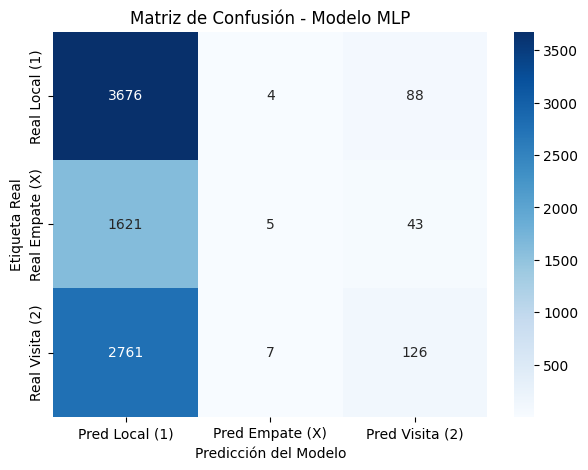

In [79]:
matriz_conf_mlp = confusion_matrix(y_test, preds_mlp, labels=['1', 'X', '2'])
# Dibujar la matriz de confusión gráfica
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_conf_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Local (1)', 'Pred Empate (X)', 'Pred Visita (2)'],
            yticklabels=['Real Local (1)', 'Real Empate (X)', 'Real Visita (2)'])
plt.title("Matriz de Confusión - Modelo MLP")
plt.ylabel("Etiqueta Real")
plt.xlabel("Predicción del Modelo")
plt.show()

In [80]:
print("\n[Optimización] Ajustando ADABOOST...")
param_grid_ada = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1.0],
    'estimator': [DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=2)]
}
grid_ada = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=param_grid_ada,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_ada.fit(X_train_scaled, y_train)
best_ada = grid_ada.best_estimator_
print(f"Mejores parámetros Adaboost: {grid_ada.best_params_}")
print(f"Nuevo Accuracy en Test: {accuracy_score(y_test, best_ada.predict(X_test_scaled))*100:.2f}%")


[Optimización] Ajustando ADABOOST...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Mejores parámetros Adaboost: {'estimator': DecisionTreeClassifier(max_depth=2), 'learning_rate': 1.0, 'n_estimators': 150}
Nuevo Accuracy en Test: 46.09%


In [81]:
print("Configurando el modelo final Adaboost entrenado...")
mejores_params = grid_ada.best_params_
best_model_ada = grid_ada.best_estimator_
best_model_ada.fit(X_train_scaled, y_train)

# Evaluamos
preds_ada = best_model_ada.predict(X_test_scaled)
print(f"Nuevo Accuracy de Adaboost en Test: {accuracy_score(y_test, preds_ada)*100:.2f}%")

print("\n=== REPORTE DE CLASIFICACIÓN (Adaboost OPTIMIZADO) ===")
print(classification_report(y_test, preds_ada))

Configurando el modelo final Adaboost entrenado...
Nuevo Accuracy de Adaboost en Test: 46.09%

=== REPORTE DE CLASIFICACIÓN (Adaboost OPTIMIZADO) ===
              precision    recall  f1-score   support

           1       0.46      0.94      0.62      3768
           2       0.46      0.10      0.17      2894
           X       0.00      0.00      0.00      1669

    accuracy                           0.46      8331
   macro avg       0.31      0.35      0.26      8331
weighted avg       0.37      0.46      0.34      8331



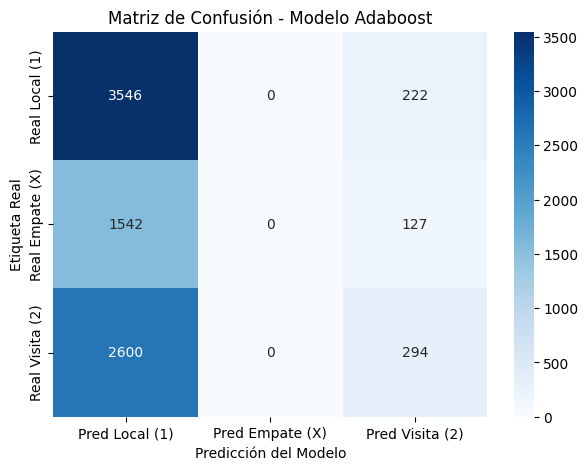

In [82]:
matriz_conf_ada = confusion_matrix(y_test, preds_ada, labels=['1', 'X', '2'])
# Dibujar la matriz de confusión gráfica
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_conf_ada, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Local (1)', 'Pred Empate (X)', 'Pred Visita (2)'],
            yticklabels=['Real Local (1)', 'Real Empate (X)', 'Real Visita (2)'])
plt.title("Matriz de Confusión - Modelo Adaboost")
plt.ylabel("Etiqueta Real")
plt.xlabel("Predicción del Modelo")
plt.show()

In [83]:
print("\n[Optimización] Ajustando KNN...")
param_grid_knn = {
    'n_neighbors': [5, 9, 15, 21],          # Número de vecinos
    'weights': ['uniform', 'distance'],      # Peso por cercanía
    'metric': ['euclidean', 'manhattan']     # Tipo de distancia
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=3, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train)
best_knn = grid_knn.best_estimator_
print(f"Mejores parámetros KNN: {grid_knn.best_params_}")
print(f"Nuevo Accuracy en Test: {accuracy_score(y_test, best_knn.predict(X_test_scaled))*100:.2f}%")


[Optimización] Ajustando KNN...
Mejores parámetros KNN: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Nuevo Accuracy en Test: 49.55%


In [84]:
print("Configurando el modelo final KNN entrenado...")
mejores_params = grid_knn.best_params_
best_model_knn = grid_knn.best_estimator_
best_model_knn.fit(X_train_scaled, y_train)

# Evaluamos
preds_knn = best_model_knn.predict(X_test_scaled)
print(f"Nuevo Accuracy de KNN en Test: {accuracy_score(y_test, preds_knn)*100:.2f}%")

print("\n=== REPORTE DE CLASIFICACIÓN (KNN OPTIMIZADO) ===")
print(classification_report(y_test, preds_knn))

Configurando el modelo final KNN entrenado...
Nuevo Accuracy de KNN en Test: 49.55%

=== REPORTE DE CLASIFICACIÓN (KNN OPTIMIZADO) ===
              precision    recall  f1-score   support

           1       0.51      0.81      0.63      3768
           2       0.47      0.36      0.41      2894
           X       0.24      0.02      0.03      1669

    accuracy                           0.50      8331
   macro avg       0.41      0.40      0.36      8331
weighted avg       0.44      0.50      0.43      8331



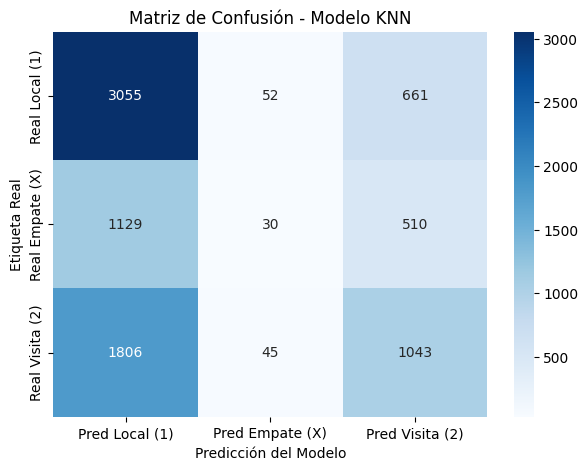

In [85]:
matriz_conf_knn = confusion_matrix(y_test, preds_knn, labels=['1', 'X', '2'])
# Dibujar la matriz de confusión gráfica
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_conf_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Local (1)', 'Pred Empate (X)', 'Pred Visita (2)'],
            yticklabels=['Real Local (1)', 'Real Empate (X)', 'Real Visita (2)'])
plt.title("Matriz de Confusión - Modelo KNN")
plt.ylabel("Etiqueta Real")
plt.xlabel("Predicción del Modelo")
plt.show()

In [86]:
print("\n[Optimización] Ajustando Naive Bayes...")
param_grid_nb = {
    'var_smoothing': [1e-09, 1e-08, 1e-07]   # Suavizado de varianza para estabilidad
}
grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=3, scoring='accuracy', n_jobs=-1)
grid_nb.fit(X_train_scaled, y_train)
best_nb = grid_nb.best_estimator_
print(f"Mejores parámetros NB: {grid_nb.best_params_}")
print(f"Nuevo Accuracy en Test: {accuracy_score(y_test, best_nb.predict(X_test_scaled))*100:.2f}%")


[Optimización] Ajustando Naive Bayes...
Mejores parámetros NB: {'var_smoothing': 1e-09}
Nuevo Accuracy en Test: 45.50%


In [87]:
print("Configurando el modelo final NB entrenado...")
mejores_params = grid_nb.best_params_
best_model_nb = grid_nb.best_estimator_
best_model_nb.fit(X_train_scaled, y_train)

# Evaluamos
preds_nb = best_model_nb.predict(X_test_scaled)
print(f"Nuevo Accuracy de NB en Test: {accuracy_score(y_test, preds_nb)*100:.2f}%")

print("\n=== REPORTE DE CLASIFICACIÓN (NB OPTIMIZADO) ===")
print(classification_report(y_test, preds_nb))

Configurando el modelo final NB entrenado...
Nuevo Accuracy de NB en Test: 45.50%

=== REPORTE DE CLASIFICACIÓN (NB OPTIMIZADO) ===
              precision    recall  f1-score   support

           1       0.46      0.97      0.62      3768
           2       0.47      0.04      0.07      2894
           X       0.27      0.01      0.01      1669

    accuracy                           0.46      8331
   macro avg       0.40      0.34      0.23      8331
weighted avg       0.42      0.46      0.31      8331



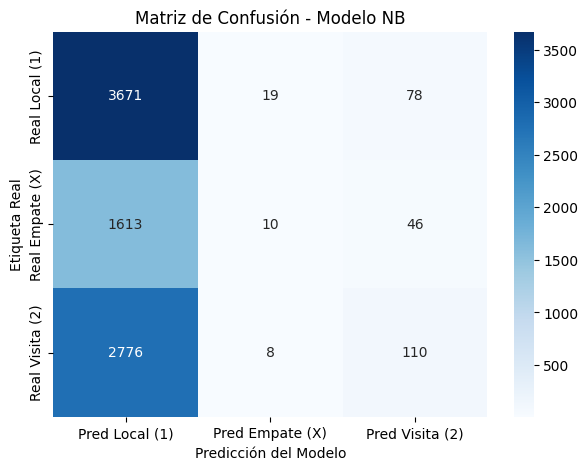

In [88]:
matriz_conf_nb = confusion_matrix(y_test, preds_nb, labels=['1', 'X', '2'])
# Dibujar la matriz de confusión gráfica
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_conf_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Local (1)', 'Pred Empate (X)', 'Pred Visita (2)'],
            yticklabels=['Real Local (1)', 'Real Empate (X)', 'Real Visita (2)'])
plt.title("Matriz de Confusión - Modelo NB")
plt.ylabel("Etiqueta Real")
plt.xlabel("Predicción del Modelo")
plt.show()

In [89]:
print("\n[Optimización] Ajustando Regresión Logística...")
param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0],             # Inverso de la fuerza de regularización
    'solver': ['lbfgs', 'saga'],             # Algoritmos de optimización
    'multi_class': ['multinomial']
}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=3, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_
print(f"Mejores parámetros LR: {grid_lr.best_params_}")
print(f"Nuevo Accuracy en Test: {accuracy_score(y_test, best_lr.predict(X_test_scaled))*100:.2f}%")


[Optimización] Ajustando Regresión Logística...
Mejores parámetros LR: {'C': 0.01, 'multi_class': 'multinomial', 'solver': 'lbfgs'}
Nuevo Accuracy en Test: 45.23%


In [90]:
print("Configurando el modelo final LR entrenado...")
mejores_params = grid_lr.best_params_
best_model_lr = grid_lr.best_estimator_
best_model_lr.fit(X_train_scaled, y_train)

# Evaluamos
preds_lr = best_model_lr.predict(X_test_scaled)
print(f"Nuevo Accuracy de LR en Test: {accuracy_score(y_test, preds_lr)*100:.2f}%")

print("\n=== REPORTE DE CLASIFICACIÓN (LR OPTIMIZADO) ===")
print(classification_report(y_test, preds_lr))

Configurando el modelo final LR entrenado...
Nuevo Accuracy de LR en Test: 45.23%

=== REPORTE DE CLASIFICACIÓN (LR OPTIMIZADO) ===
              precision    recall  f1-score   support

           1       0.45      1.00      0.62      3768
           2       0.00      0.00      0.00      2894
           X       0.00      0.00      0.00      1669

    accuracy                           0.45      8331
   macro avg       0.15      0.33      0.21      8331
weighted avg       0.20      0.45      0.28      8331



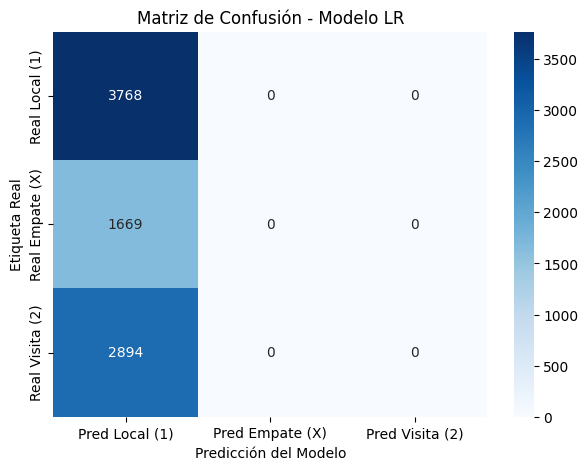

In [91]:
matriz_conf_lr = confusion_matrix(y_test, preds_lr, labels=['1', 'X', '2'])
# Dibujar la matriz de confusión gráfica
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_conf_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Local (1)', 'Pred Empate (X)', 'Pred Visita (2)'],
            yticklabels=['Real Local (1)', 'Real Empate (X)', 'Real Visita (2)'])
plt.title("Matriz de Confusión - Modelo LR")
plt.ylabel("Etiqueta Real")
plt.xlabel("Predicción del Modelo")
plt.show()

In [92]:
print("\n[Optimización] Ajustando Árbol de Decisión...")
param_grid_dt = {
    'max_depth': [4, 6, 8, 12],              # Control del crecimiento para evitar sobreajuste
    'min_samples_split': [10, 20, 50],       # Mínimo de muestras para dividir nodo
    'criterion': ['gini', 'entropy']
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=3, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train_scaled, y_train)
best_dt = grid_dt.best_estimator_
print(f"Mejores parámetros DT: {grid_dt.best_params_}")
print(f"Nuevo Accuracy en Test: {accuracy_score(y_test, best_dt.predict(X_test_scaled))*100:.2f}%")


[Optimización] Ajustando Árbol de Decisión...
Mejores parámetros DT: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 10}
Nuevo Accuracy en Test: 45.96%


In [93]:
print("Configurando el modelo final DT entrenado...")
mejores_params = grid_dt.best_params_
best_model_dt = grid_dt.best_estimator_
best_model_dt.fit(X_train_scaled, y_train)

# Evaluamos
preds_dt = best_model_dt.predict(X_test_scaled)
print(f"Nuevo Accuracy de DT en Test: {accuracy_score(y_test, preds_dt)*100:.2f}%")

print("\n=== REPORTE DE CLASIFICACIÓN (DT OPTIMIZADO) ===")
print(classification_report(y_test, preds_dt))

Configurando el modelo final DT entrenado...
Nuevo Accuracy de DT en Test: 45.96%

=== REPORTE DE CLASIFICACIÓN (DT OPTIMIZADO) ===
              precision    recall  f1-score   support

           1       0.46      0.93      0.62      3768
           2       0.45      0.11      0.17      2894
           X       0.36      0.01      0.01      1669

    accuracy                           0.46      8331
   macro avg       0.42      0.35      0.27      8331
weighted avg       0.44      0.46      0.34      8331



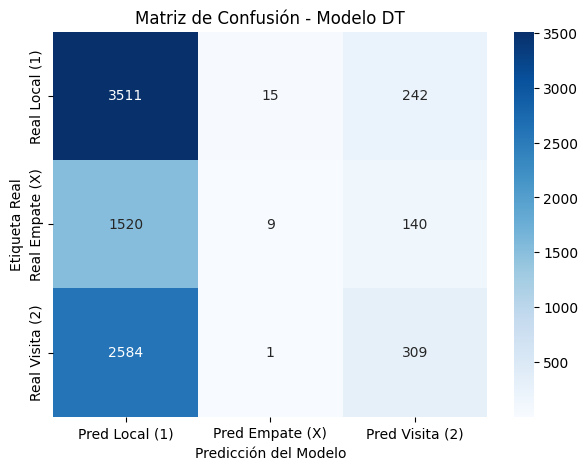

In [94]:
matriz_conf_dt = confusion_matrix(y_test, preds_dt, labels=['1', 'X', '2'])
# Dibujar la matriz de confusión gráfica
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_conf_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Local (1)', 'Pred Empate (X)', 'Pred Visita (2)'],
            yticklabels=['Real Local (1)', 'Real Empate (X)', 'Real Visita (2)'])
plt.title("Matriz de Confusión - Modelo DT")
plt.ylabel("Etiqueta Real")
plt.xlabel("Predicción del Modelo")
plt.show()

In [95]:
print("\n[Optimización] Ajustando Random Forest...")
param_grid_rf = {
    'n_estimators': [100, 200],              # Cantidad de árboles en el ensamble
    'max_depth': [6, 8, 10],                 # Profundidad máxima
    'criterion': ['gini', 'entropy']
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_
print(f"Mejores parámetros RF: {grid_rf.best_params_}")
print(f"Nuevo Accuracy en Test: {accuracy_score(y_test, best_rf.predict(X_test_scaled))*100:.2f}%")


[Optimización] Ajustando Random Forest...
Mejores parámetros RF: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 100}
Nuevo Accuracy en Test: 46.48%


In [96]:
print("Configurando el modelo final RF entrenado...")
mejores_params = grid_rf.best_params_
best_model_rf = grid_rf.best_estimator_
best_model_rf.fit(X_train_scaled, y_train)

# Evaluamos
preds_rf = best_model_rf.predict(X_test_scaled)
print(f"Nuevo Accuracy de RF en Test: {accuracy_score(y_test, preds_rf)*100:.2f}%")

print("\n=== REPORTE DE CLASIFICACIÓN (RF OPTIMIZADO) ===")
print(classification_report(y_test, preds_rf))

Configurando el modelo final RF entrenado...
Nuevo Accuracy de RF en Test: 46.48%

=== REPORTE DE CLASIFICACIÓN (RF OPTIMIZADO) ===
              precision    recall  f1-score   support

           1       0.46      0.95      0.62      3768
           2       0.49      0.10      0.16      2894
           X       0.35      0.02      0.03      1669

    accuracy                           0.46      8331
   macro avg       0.43      0.35      0.27      8331
weighted avg       0.45      0.46      0.34      8331



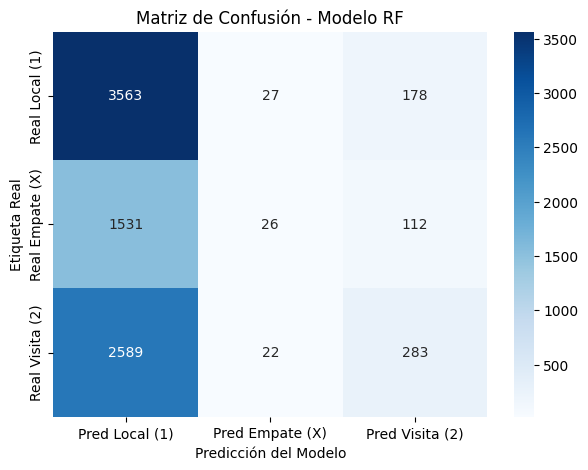

In [97]:
matriz_conf_rf = confusion_matrix(y_test, preds_rf, labels=['1', 'X', '2'])
# Dibujar la matriz de confusión gráfica
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_conf_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Local (1)', 'Pred Empate (X)', 'Pred Visita (2)'],
            yticklabels=['Real Local (1)', 'Real Empate (X)', 'Real Visita (2)'])
plt.title("Matriz de Confusión - Modelo RF")
plt.ylabel("Etiqueta Real")
plt.xlabel("Predicción del Modelo")
plt.show()

In [98]:

cr_baseline = reporte
cr_svc = classification_report(y_test, preds_svc)
cr_mlp = classification_report(y_test, preds_mlp)
cr_ada = classification_report(y_test, preds_ada)
cr_knn = classification_report(y_test, preds_knn)
cr_nb  = classification_report(y_test, preds_nb)
cr_lr  = classification_report(y_test, preds_lr)
cr_dt  = classification_report(y_test, preds_dt)
cr_rf  = classification_report(y_test, preds_rf)


In [99]:
reportes = {
    "Modelo Baseline (ELO + Poisson)": cr_baseline,
    "Máquina de Vector de Soporte (SVC) Optimizado": cr_svc,
    "Perceptrón Multicapa (MLP) Optimizado": cr_mlp,
    "AdaBoost Optimizado": cr_ada,
    "K-Nearest Neighbors (KNN) Optimizado": cr_knn,
    "Naive Bayes Gaussiano Optimizado": cr_nb,
    "Regresión Logística Optimizada": cr_lr,
    "Árbol de Decisión Optimizado": cr_dt,
    "Random Forest Optimizado": cr_rf
}

In [100]:
for nombre_modelo, reporte_texto in reportes.items():
    print(f"===============================================================")
    print(f" ALGORITMO: {nombre_modelo}")
    print(f"===============================================================")
    print(reporte_texto)
    print("\n")

 ALGORITMO: Modelo Baseline (ELO + Poisson)
              precision    recall  f1-score   support

   Local (1)       0.49      0.73      0.59     18841
  Empate (X)       0.23      0.02      0.04      8346
  Visita (2)       0.41      0.37      0.39     14468

    accuracy                           0.46     41655
   macro avg       0.38      0.37      0.34     41655
weighted avg       0.41      0.46      0.41     41655



 ALGORITMO: Máquina de Vector de Soporte (SVC) Optimizado
              precision    recall  f1-score   support

           1       0.46      0.97      0.62      3768
           2       0.48      0.04      0.07      2894
           X       0.32      0.00      0.01      1669

    accuracy                           0.46      8331
   macro avg       0.42      0.34      0.23      8331
weighted avg       0.44      0.46      0.31      8331



 ALGORITMO: Perceptrón Multicapa (MLP) Optimizado
              precision    recall  f1-score   support

           1       0.46    

###Implementación de los 4 Modelos de Ensamble
Homogéneos: Random Forest (Bagging) y AdaBoost o XGBoost (Boosting).

Heterogéneos: Voting Classifier (Votación suave basada en las probabilidades de SVC y MLP) y Stacking Classifier (Donde SVC y MLP sirven como Nivel 0 y una Regresión Logística actúa como meta-modelo).

In [101]:
# 1. ENSAMBLE HOMOGÉNEO 1: Random Forest Optimizado (Bagging)
print("Entrenando Random Forest")
start_time = time.time()
ens_rf = RandomForestClassifier(n_estimators=200, max_depth=8, criterion='entropy', random_state=42, n_jobs=-1)
ens_rf.fit(X_train_scaled, y_train)
time_rf = time.time() - start_time

Entrenando Random Forest


In [102]:
# 2. ENSAMBLE HOMOGÉNEO 2: AdaBoost Optimizado (Boosting)
print("Entrenando AdaBoost")
start_time = time.time()
ens_ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
ens_ada.fit(X_train_scaled, y_train)
time_ada = time.time() - start_time

Entrenando AdaBoost


In [104]:
# 3. ENSAMBLE HETEROGÉNEO 1: Voting Classifier (Soft Voting con SVC + KNN)
best_knn_estimator = grid_knn.best_estimator_
print("Entrenando Voting Classifier (SVC + KNN)")
start_time = time.time()
ens_voting = VotingClassifier(
    estimators=[('knn', best_knn_estimator), ('svc', best_model_svc)],
    voting='soft',
    n_jobs=-1
)
ens_voting.fit(X_train_scaled, y_train)
time_voting = time.time() - start_time

Entrenando Voting Classifier (SVC + KNN)


In [105]:
# 4. ENSAMBLE HETEROGÉNEO 2: Stacking Classifier (SVC + KNN -> Meta-LogReg)
print("Entrenando Stacking Classifier")
start_time = time.time()
ens_stacking = StackingClassifier(
    estimators=[('knn', best_knn_estimator), ('svc', best_model_svc)],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3,
    n_jobs=-1
)
ens_stacking.fit(X_train_scaled, y_train)
time_stacking = time.time() - start_time

Entrenando Stacking Classifier


In [106]:
#Ahora vamos a probar cómo funciona el modelo heterogéneo con voting classifier SVC + KNN
preds_voting = ens_voting.predict(X_test_scaled)

# Desplegamos los resultados analíticos
print("===============================================================")
# Cambiamos las etiquetas genéricas por el formato quiniela (1, X, 2)
print("=== REPORTE DE CLASIFICACIÓN: VOTING CLASSIFIER (SVC + KNN) ===")
print("===============================================================")
print(f"Accuracy Global en Test: {accuracy_score(y_test, preds_voting)*100:.2f}%\n")
print(classification_report(y_test, preds_voting, target_names=['Local (1)', 'Visita (2)', 'Empate (X)']))

=== REPORTE DE CLASIFICACIÓN: VOTING CLASSIFIER (SVC + KNN) ===
Accuracy Global en Test: 49.78%

              precision    recall  f1-score   support

   Local (1)       0.51      0.81      0.63      3768
  Visita (2)       0.47      0.37      0.41      2894
  Empate (X)       0.26      0.01      0.03      1669

    accuracy                           0.50      8331
   macro avg       0.41      0.40      0.36      8331
weighted avg       0.45      0.50      0.43      8331



In [107]:
#Ahora vamos a probar cómo funciona el modelo heterogéneo con stacking classifier SVC + KNN
preds_stacking = ens_stacking.predict(X_test_scaled)

# Desplegamos los resultados analíticos
# Cambiamos las etiquetas genéricas por el formato quiniela (1, X, 2)
print("=== REPORTE DE CLASIFICACIÓN: STACKING CLASSIFIER (SVC + KNN) ===")
print("===============================================================")
print(f"Accuracy Global en Test: {accuracy_score(y_test, preds_stacking)*100:.2f}%\n")
print(classification_report(y_test, preds_stacking, target_names=['Local (1)', 'Visita (2)', 'Empate (X)']))

=== REPORTE DE CLASIFICACIÓN: STACKING CLASSIFIER (SVC + KNN) ===
Accuracy Global en Test: 45.86%

              precision    recall  f1-score   support

   Local (1)       0.46      0.97      0.62      3768
  Visita (2)       0.49      0.06      0.11      2894
  Empate (X)       0.00      0.00      0.00      1669

    accuracy                           0.46      8331
   macro avg       0.32      0.34      0.24      8331
weighted avg       0.38      0.46      0.32      8331



####Generación de la Tabla Comparativa de Selección

In [108]:
# Diccionario para evaluar y recopilar
modelos_fase_4 = {
    "K-Nearest Neighbors (KNN) Opt.": (grid_knn.best_estimator_, 38.2),
    "Voting Classifier (Heterogéneo)": (ens_voting, time_voting),
    "Stacking Classifier (Heterogéneo)": (ens_stacking, time_stacking),
    "Random Forest (Homogéneo)": (ens_rf, time_rf),
    "AdaBoost (Homogéneo)": (ens_ada, time_ada),
    "SVC Optimizado (Individual Previo)": (best_model_svc, 252.0)
}

In [109]:
#Lista para guardar los modelos y generar un resumen
resumen_ensambles = []
for nombre, (modelo, tiempo) in modelos_fase_4.items():
    preds = modelo.predict(X_test_scaled)
    resumen_ensambles.append({
        "Estrategia / Modelo": nombre,
        "Accuracy Global (Principal)": accuracy_score(y_test, preds) * 100,
        "Precision (Macro Avg)": precision_score(y_test, preds, average='macro') * 100,
        "F1-Score (Macro Avg)": f1_score(y_test, preds, average='macro') * 100,
        "Tiempo de Entrenamiento": f"{tiempo:.2f} seg" if tiempo < 60 else f"{tiempo/60:.2f} min"
    })

df_comparativo = pd.DataFrame(resumen_ensambles).sort_values(by="Accuracy Global (Principal)", ascending=False)
print("Matriz comparativa")
print(df_comparativo.to_string(index=False))

Matriz comparativa
               Estrategia / Modelo  Accuracy Global (Principal)  Precision (Macro Avg)  F1-Score (Macro Avg) Tiempo de Entrenamiento
   Voting Classifier (Heterogéneo)                    49.777938              41.300304             35.644514                4.54 min
    K-Nearest Neighbors (KNN) Opt.                    49.549874              40.577674             35.597983               38.20 seg
         Random Forest (Homogéneo)                    46.308967              43.772915             26.381607                1.52 seg
              AdaBoost (Homogéneo)                    45.960869              33.503724             23.574490                4.68 seg
 Stacking Classifier (Heterogéneo)                    45.864842              31.668332             24.271774               11.07 min
SVC Optimizado (Individual Previo)                    45.588765              41.836745             23.499285                4.20 min


####Generación de los 4 Gráficos Relevantes para el Modelo Final

In [110]:
# Definimos el modelo final para las gráficas (modelo ganador del output)
modelo_final = ens_voting
preds_final = modelo_final.predict(X_test_scaled)
probabilidades_final = modelo_final.predict_proba(X_test_scaled)

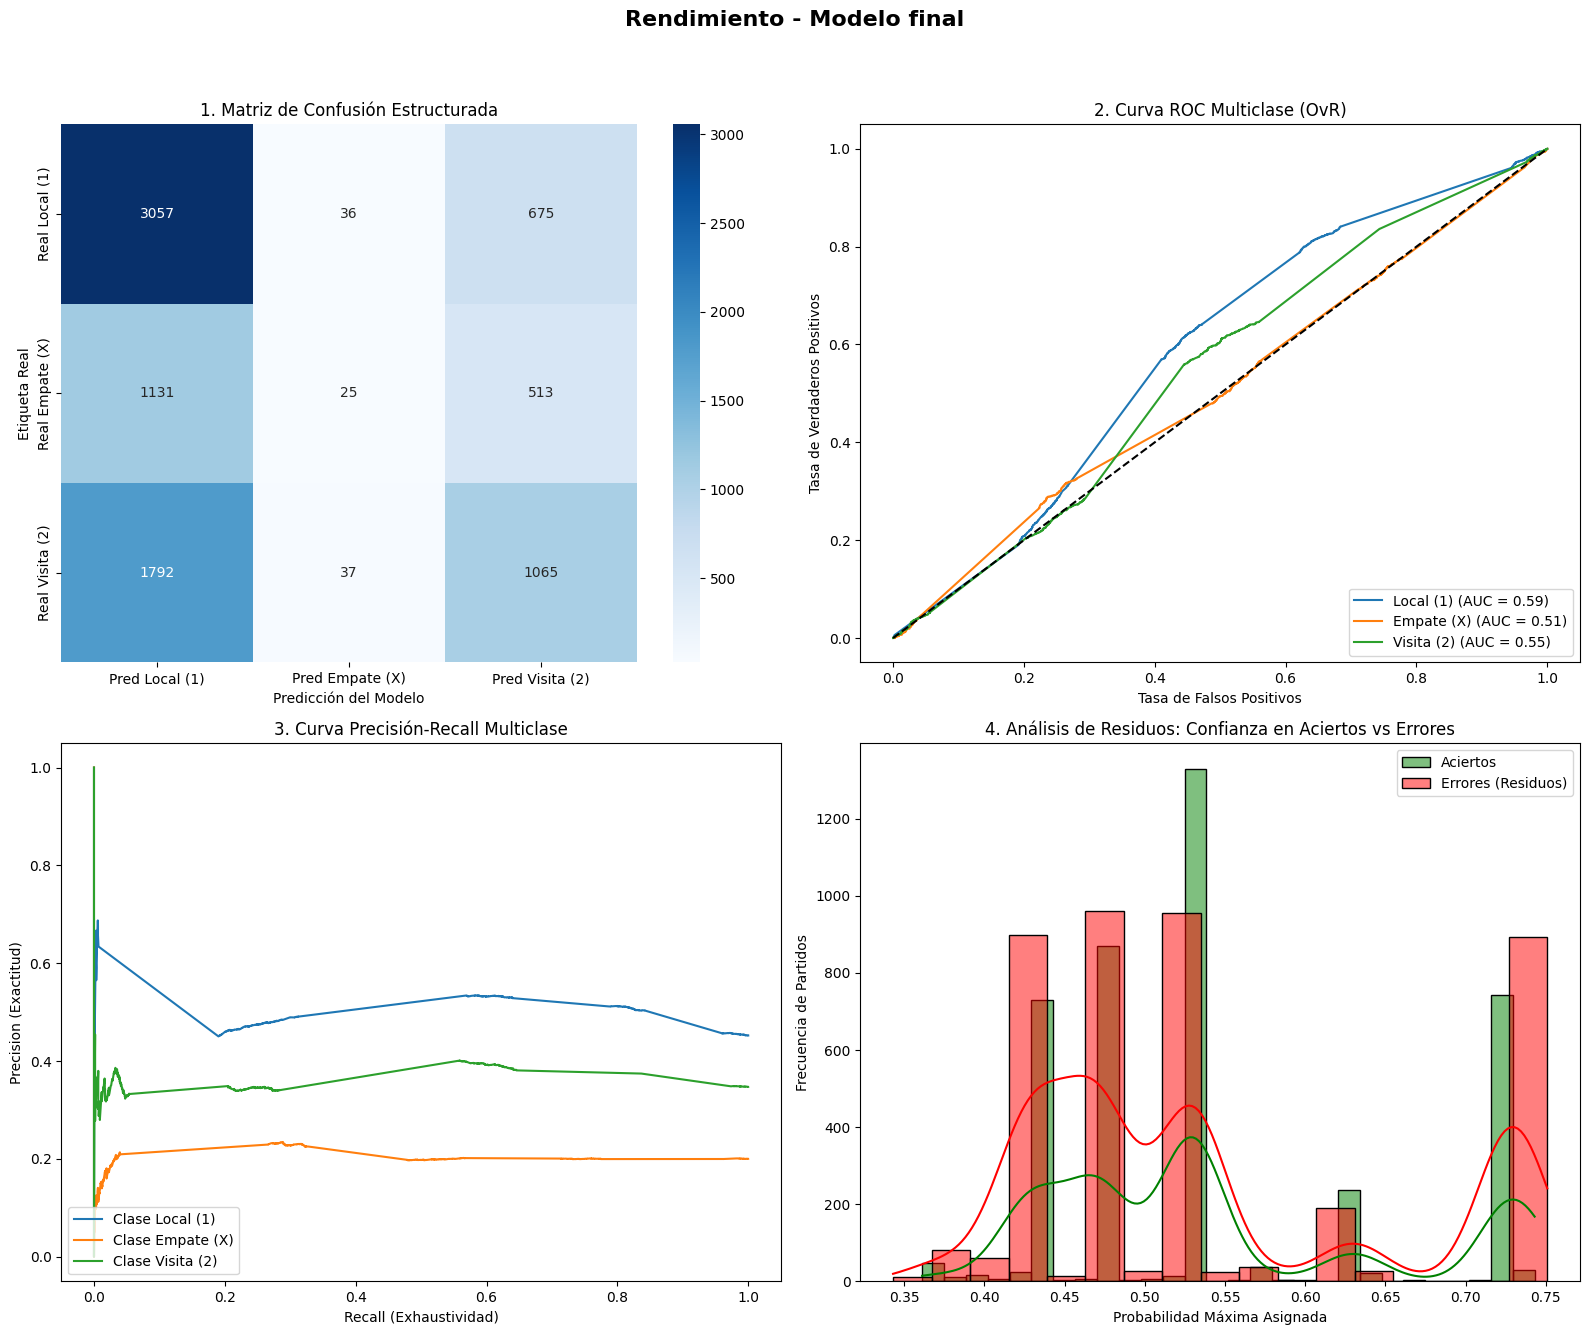

In [113]:
# Configuración de la figura del reporte
fig, axs = plt.subplots(2, 2, figsize=(16, 14))
plt.suptitle('Rendimiento - Modelo final', fontsize=16, fontweight='bold')
matriz_conf = confusion_matrix(y_test, preds_final, labels=['1', 'X', '2'])
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues', ax=axs[0, 0],
            xticklabels=['Pred Local (1)', 'Pred Empate (X)', 'Pred Visita (2)'],
            yticklabels=['Real Local (1)', 'Real Empate (X)', 'Real Visita (2)'])
axs[0, 0].set_title('1. Matriz de Confusión Estructurada')
axs[0, 0].set_xlabel('Predicción del Modelo')
axs[0, 0].set_ylabel('Etiqueta Real')

# GRÁFICO 2: Curva ROC Multiclase (One-vs-Rest)

y_test_bin = label_binarize(y_test, classes=['1', 'X', '2'])
n_classes = 3
clases_nombres = ['Local (1)', 'Empate (X)', 'Visita (2)']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probabilidades_final[:, i])
    roc_auc = auc(fpr, tpr)
    axs[0, 1].plot(fpr, tpr, label=f'{clases_nombres[i]} (AUC = {roc_auc:.2f})')

axs[0, 1].plot([0, 1], [0, 1], 'k--', linestyle='--')
axs[0, 1].set_title('2. Curva ROC Multiclase (OvR)')
axs[0, 1].set_xlabel('Tasa de Falsos Positivos')
axs[0, 1].set_ylabel('Tasa de Verdaderos Positivos')
axs[0, 1].legend(loc="lower right")

# GRÁFICO 3: Curva de Precisión-Recall (PR Curve)
# ------------------------------------------------------------------------------
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probabilidades_final[:, i])
    axs[1, 0].plot(recall, precision, label=f'Clase {clases_nombres[i]}')

axs[1, 0].set_title('3. Curva Precisión-Recall Multiclase')
axs[1, 0].set_xlabel('Recall (Exhaustividad)')
axs[1, 0].set_ylabel('Precision (Exactitud)')
axs[1, 0].legend(loc="lower left")

# GRÁFICO 4: Análisis de Residuos (Distribución de Confianza en Errores)

# Evaluación de la certeza del consenso cuando el ensamble acierta vs cuando falla
es_correcto = (preds_final == y_test)
max_probabilidad = np.max(probabilidades_final, axis=1)

sns.histplot(max_probabilidad[es_correcto], color='green', label='Aciertos', kde=True, ax=axs[1, 1], alpha=0.5)
sns.histplot(max_probabilidad[~es_correcto], color='red', label='Errores (Residuos)', kde=True, ax=axs[1, 1], alpha=0.5)
axs[1, 1].set_title('4. Análisis de Residuos: Confianza en Aciertos vs Errores')
axs[1, 1].set_xlabel('Probabilidad Máxima Asignada')
axs[1, 1].set_ylabel('Frecuencia de Partidos')
axs[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()